# Switch4Schools — Emotional Intelligence Analysis
**Merged notebook (main.ipynb + main_updated.ipynb)**

Sections:
1. Imports
2. Data Cleaning Pipeline (how studentCheckIn_cleaned.csv was created)
3. Load & Prepare Cleaned Data
4. Campus & Class Filtering Utilities
5. Build Class-Session-Student Relationships
6. Identify Top Classes
7. Student Wellbeing Profiles
8. Class Emotional Profiles
9. Emotional Trend Analysis
10. Generate Class Recommendations
11. Save All Results


## 1. Import Required Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
import json
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Try to import tqdm for progress bars
try:
    from tqdm import tqdm
    tqdm_available = True
except ImportError:
    tqdm_available = False
    def tqdm(iterable, desc="Processing"):
        print(f"{desc}...")
        return iterable

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully")

try:
    from tabulate import tabulate
except ImportError:
    tabulate = None
    print('tabulate not installed — run: pip install tabulate')


Libraries imported successfully


## 2. Data Cleaning Pipeline
This section shows how `datasets/studentCheckIn_cleaned.csv` was produced from the raw `datasets/studentCheckIn.csv`.
**Skip to Section 3 if you are starting from the already-cleaned file.**

In [5]:
### Step 1: Create Backup and Load Student Check-in Data

import shutil
from datetime import datetime

def create_backup():
    """Create timestamped backup of student check-in data"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    backup_filename = f"datasets/studentCheckIn_backup_{timestamp}.csv"
    
    shutil.copy2("datasets/studentCheckIn.csv", backup_filename)
    print(f"  Backup created: {backup_filename}")
    return backup_filename

# Create backup
backup_file = create_backup()

# Load student check-in data
print(f"\n  LOADING STUDENT CHECK-IN DATA")
print("="*40)

df_student_checkins = pd.read_csv('datasets/studentCheckIn.csv')
print(f"  Student Check-ins loaded: {df_student_checkins.shape}")
print(f"   Columns: {list(df_student_checkins.columns)}")

# Display current statistics
print(f"\n  Current Statistics:")
print(f"   Total check-ins: {len(df_student_checkins):,}")
print(f"   Total sessions: {df_student_checkins['Check In Session ID'].nunique():,}")
print(f"   Total students: {df_student_checkins['Student ID'].nunique():,}")

# Display sample data
print(f"\n  Sample Data:")
print(df_student_checkins[['Check In Session ID', 'Student ID', 'Emotion']].head(5))


  Backup created: datasets/studentCheckIn_backup_20260320_145440.csv

  LOADING STUDENT CHECK-IN DATA
  Student Check-ins loaded: (757112, 10)
   Columns: ['Check In Session ID', 'Student Check In ID', 'Student ID', 'Absencce', 'Emotion', 'Emotion Intensity Percentage', 'Tiredness', 'Request For Chat', 'Chat Cleared', 'Eating']

  Current Statistics:
   Total check-ins: 757,112
   Total sessions: 31,149
   Total students: 11,669

  Sample Data:
                    Check In Session ID                            Student ID  \
0  178d49ba-75f4-4bb9-a78a-55bca3321773  2e4188a6-c456-46a9-9fa0-4322bc017ee5   
1  178d49ba-75f4-4bb9-a78a-55bca3321773  23ff9e76-cb80-4763-9b62-c740ade6075a   
2  178d49ba-75f4-4bb9-a78a-55bca3321773  20390f94-f3fe-4d89-a8f9-8bdb2dbe98ae   
3  178d49ba-75f4-4bb9-a78a-55bca3321773  3173234a-34c3-441d-8b72-f75b188abeff   
4  178d49ba-75f4-4bb9-a78a-55bca3321773  fda76f0d-56a8-441b-8f1e-6680564ead27   

   Emotion  
0    HAPPY  
1  EXCITED  
2    HAPPY  
3    HAPPY  

### Step 2: Analyze Duplicate Students in Sessions


In [6]:
# Analyze duplicate students within each session
print("  ANALYZING DUPLICATE STUDENTS IN SESSIONS")
print("="*45)

# Count duplicates within each session
session_duplicates = df_student_checkins.groupby('Check In Session ID')['Student ID'].apply(
    lambda x: len(x) - len(x.unique())
)

# Find sessions with duplicates
sessions_with_duplicates = session_duplicates[session_duplicates > 0]
total_duplicates = session_duplicates.sum()

print(f"  Duplicate Analysis Results:")
print(f"   Total duplicate student check-ins: {total_duplicates:,}")
print(f"   Sessions with duplicates: {len(sessions_with_duplicates):,}")
print(f"   Total sessions: {df_student_checkins['Check In Session ID'].nunique():,}")
print(f"   Sessions with duplicates percentage: {(len(sessions_with_duplicates) / df_student_checkins['Check In Session ID'].nunique() * 100):.2f}%")

# Show top sessions with most duplicates
print(f"\n  Top 10 Sessions with Most Duplicates:")
top_duplicate_sessions = sessions_with_duplicates.sort_values(ascending=False).head(10)
for session_id, duplicate_count in top_duplicate_sessions.items():
    total_in_session = len(df_student_checkins[df_student_checkins['Check In Session ID'] == session_id])
    unique_in_session = df_student_checkins[df_student_checkins['Check In Session ID'] == session_id]['Student ID'].nunique()
    print(f"   Session {session_id[:10]}...: {duplicate_count} duplicates ({total_in_session} total, {unique_in_session} unique)")

# Show example of a session with duplicates
if len(sessions_with_duplicates) > 0:
    example_session = sessions_with_duplicates.index[0]
    example_data = df_student_checkins[df_student_checkins['Check In Session ID'] == example_session][
        ['Student ID', 'Emotion', 'Emotion Intensity Percentage', 'Student Check In ID']
    ]
    print(f"\n  Example Session with Duplicates (Session: {example_session[:10]}...):")
    print(f"   Total check-ins: {len(example_data)}")
    print(f"   Unique students: {example_data['Student ID'].nunique()}")
    print(example_data.head(8))


  ANALYZING DUPLICATE STUDENTS IN SESSIONS
  Duplicate Analysis Results:
   Total duplicate student check-ins: 0
   Sessions with duplicates: 0
   Total sessions: 31,149
   Sessions with duplicates percentage: 0.00%

  Top 10 Sessions with Most Duplicates:


### Step 3: Remove Duplicate Students from Sessions


In [7]:
# Remove duplicate students from each session
print("  REMOVING DUPLICATE STUDENTS FROM SESSIONS")
print("="*45)

# Store original count
original_count = len(df_student_checkins)
print(f"  Before Cleaning:")
print(f"   Original check-ins: {original_count:,}")

# Remove duplicates - keep only the first occurrence of each student per session
df_cleaned = df_student_checkins.drop_duplicates(
    subset=['Check In Session ID', 'Student ID'], 
    keep='first'  # Keep the first occurrence of each student per session
)

# Calculate results
cleaned_count = len(df_cleaned)
duplicates_removed = original_count - cleaned_count

print(f"\n  Cleaning Results:")
print(f"   Cleaned check-ins: {cleaned_count:,}")
print(f"   Duplicates removed: {duplicates_removed:,}")
print(f"   Reduction percentage: {(duplicates_removed / original_count * 100):.2f}%")

# Update the main dataframe
df_student_checkins = df_cleaned.copy()

print(f"\n  Duplicate removal completed successfully!")
print(f"   Each student now has only one check-in per session.")


  REMOVING DUPLICATE STUDENTS FROM SESSIONS
  Before Cleaning:
   Original check-ins: 757,112

  Cleaning Results:
   Cleaned check-ins: 757,112
   Duplicates removed: 0
   Reduction percentage: 0.00%

  Duplicate removal completed successfully!
   Each student now has only one check-in per session.


### Step 4: Verify Cleanup Results


In [8]:
# Verify that duplicates have been removed
print("  VERIFYING CLEANUP RESULTS")
print("="*35)

# Check for remaining duplicates
remaining_duplicates = df_student_checkins.groupby(['Check In Session ID', 'Student ID']).size()
remaining_duplicate_count = (remaining_duplicates > 1).sum()

print(f"  Verification Results:")
print(f"   Sessions with duplicate students remaining: {remaining_duplicate_count}")
print(f"   Duplicates successfully removed: {'  Yes' if remaining_duplicate_count == 0 else '  No'}")

# Updated statistics
print(f"\n  Updated Dataset Statistics:")
print(f"   Total check-ins: {len(df_student_checkins):,}")
print(f"   Total sessions: {df_student_checkins['Check In Session ID'].nunique():,}")
print(f"   Total students: {df_student_checkins['Student ID'].nunique():,}")

# Check data integrity
print(f"\n  Data Integrity Check:")
print(f"   Shape: {df_student_checkins.shape}")
print(f"   Columns: {list(df_student_checkins.columns)}")

# Check for missing values
print(f"\n  Missing Values Analysis:")
missing_summary = df_student_checkins.isnull().sum()
for col, missing_count in missing_summary.items():
    if missing_count > 0:
        percentage = (missing_count / len(df_student_checkins)) * 100
        print(f"   {col}: {missing_count:,} ({percentage:.2f}%)")

# Check data quality
print(f"\n  Data Quality Check:")
print(f"   Emotion values: {df_student_checkins['Emotion'].value_counts().head()}")
print(f"   Emotion Intensity range: {df_student_checkins['Emotion Intensity Percentage'].min()} - {df_student_checkins['Emotion Intensity Percentage'].max()}")
print(f"   Tiredness range: {df_student_checkins['Tiredness'].min()} - {df_student_checkins['Tiredness'].max()}")

print(f"\n  Cleanup verification completed successfully!")


  VERIFYING CLEANUP RESULTS
  Verification Results:
   Sessions with duplicate students remaining: 0
   Duplicates successfully removed:   Yes

  Updated Dataset Statistics:
   Total check-ins: 757,112
   Total sessions: 31,149
   Total students: 11,669

  Data Integrity Check:
   Shape: (757112, 10)
   Columns: ['Check In Session ID', 'Student Check In ID', 'Student ID', 'Absencce', 'Emotion', 'Emotion Intensity Percentage', 'Tiredness', 'Request For Chat', 'Chat Cleared', 'Eating']

  Missing Values Analysis:
   Chat Cleared: 22,098 (2.92%)
   Eating: 493,920 (65.24%)

  Data Quality Check:
   Emotion values: Emotion
HAPPY        471008
EXCITED      146099
undefined     47484
ANXIOUS       31497
SAD           28018
Name: count, dtype: int64
   Emotion Intensity range: 0.14 - undefined
   Tiredness range: 1 - undefined

  Cleanup verification completed successfully!


### Step 5: Save Cleaned Data


In [9]:
# Save the cleaned dataset
print("  SAVING CLEANED DATA")
print("="*25)

# Save cleaned data to CSV
cleaned_filename = "datasets/studentCheckIn_cleaned.csv"
df_student_checkins.to_csv(cleaned_filename, index=False)
print(f"  Cleaned data saved to: {cleaned_filename}")

# Also save as the main file (replace original)
df_student_checkins.to_csv("datasets/studentCheckIn.csv", index=False)
print(f"  Original file updated with cleaned data")

# Final summary
print(f"\n  FINAL SUMMARY:")
print(f"   Original check-ins: {original_count:,}")
print(f"   Cleaned check-ins: {len(df_student_checkins):,}")
print(f"   Duplicates removed: {duplicates_removed:,}")
print(f"   Reduction percentage: {(duplicates_removed / original_count * 100):.2f}%")
print(f"   Backup file: {backup_file}")
print(f"   Cleaned file: {cleaned_filename}")

print(f"\n  Data cleaning completed successfully!")
print(f"   Your dataset is now ready for emotion analysis!")


  SAVING CLEANED DATA
  Cleaned data saved to: datasets/studentCheckIn_cleaned.csv
  Original file updated with cleaned data

  FINAL SUMMARY:
   Original check-ins: 757,112
   Cleaned check-ins: 757,112
   Duplicates removed: 0
   Reduction percentage: 0.00%
   Backup file: datasets/studentCheckIn_backup_20260320_145440.csv
   Cleaned file: datasets/studentCheckIn_cleaned.csv

  Data cleaning completed successfully!
   Your dataset is now ready for emotion analysis!


## Load and Prepare Data


Loading datasets...
Student check-ins: (757112, 10)
Classes: (583, 3)
Sessions: (31149, 3)
Students: (12467, 7)
Teacher-Class: (3754, 2)


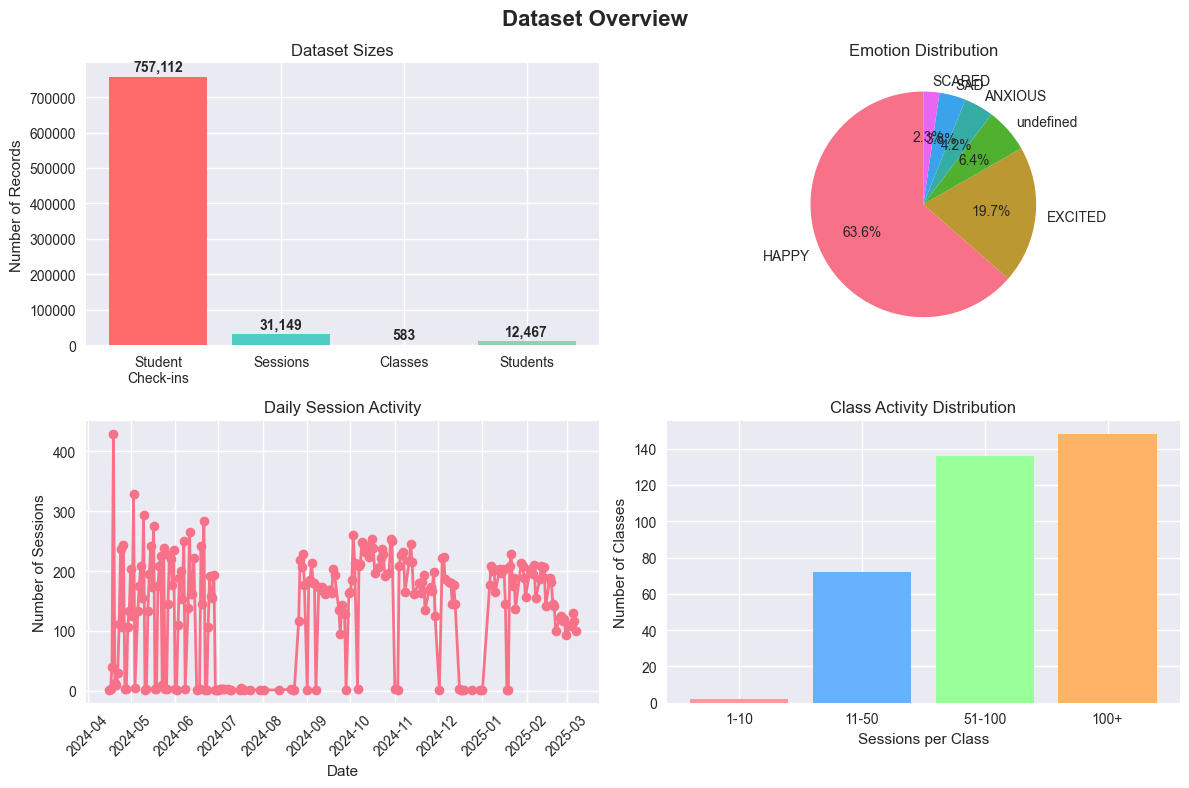

Data loading completed successfully


In [10]:
# Load all required datasets
print("Loading datasets...")

# Load cleaned student check-ins
df_student_checkins = pd.read_csv('datasets/studentCheckIn_cleaned.csv')
print(f"Student check-ins: {df_student_checkins.shape}")

# Load other datasets
df_classes = pd.read_csv('datasets/class.csv')
df_sessions = pd.read_csv('datasets/checkInSession.csv')
df_students = pd.read_csv('datasets/students.csv')
df_teacher_class = pd.read_csv('datasets/teacherClass.csv')

print(f"Classes: {df_classes.shape}")
print(f"Sessions: {df_sessions.shape}")
print(f"Students: {df_students.shape}")
print(f"Teacher-Class: {df_teacher_class.shape}")

# Display basic dataset info
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Dataset Overview', fontsize=16, fontweight='bold')

# Dataset sizes visualization
dataset_sizes = [
    len(df_student_checkins),
    len(df_sessions), 
    len(df_classes),
    len(df_students)
]
dataset_names = ['Student\nCheck-ins', 'Sessions', 'Classes', 'Students']

bars = axes[0,0].bar(dataset_names, dataset_sizes, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[0,0].set_title('Dataset Sizes')
axes[0,0].set_ylabel('Number of Records')
for bar, size in zip(bars, dataset_sizes):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(dataset_sizes)*0.01,
                   f'{size:,}', ha='center', va='bottom', fontweight='bold')

# Emotion distribution
emotion_counts = df_student_checkins['Emotion'].value_counts().head(6)
axes[0,1].pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%', startangle=90)
axes[0,1].set_title('Emotion Distribution')

# Session activity over time
df_sessions['Opened Date Time'] = pd.to_datetime(df_sessions['Opened Date Time'])
daily_sessions = df_sessions.groupby(df_sessions['Opened Date Time'].dt.date).size()
axes[1,0].plot(daily_sessions.index, daily_sessions.values, marker='o', linewidth=2)
axes[1,0].set_title('Daily Session Activity')
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('Number of Sessions')
axes[1,0].tick_params(axis='x', rotation=45)

# Class activity levels
class_activity = df_sessions.groupby('Class ID').size()
activity_ranges = ['1-10', '11-50', '51-100', '100+']
activity_counts = [
    len(class_activity[(class_activity >= 1) & (class_activity <= 10)]),
    len(class_activity[(class_activity >= 11) & (class_activity <= 50)]),
    len(class_activity[(class_activity >= 51) & (class_activity <= 100)]),
    len(class_activity[class_activity > 100])
]
axes[1,1].bar(activity_ranges, activity_counts, color=['#FF9999', '#66B2FF', '#99FF99', '#FFB366'])
axes[1,1].set_title('Class Activity Distribution')
axes[1,1].set_xlabel('Sessions per Class')
axes[1,1].set_ylabel('Number of Classes')

plt.tight_layout()
plt.show()

print("Data loading completed successfully")


## 4. Campus & Class Filtering Utilities
Helper functions to filter sessions by campus and class name.
These are useful for targeted analysis of a specific school or class.

In [11]:
import pandas as pd
from tqdm import tqdm

def filter_checkin_sessions(campus_id, classgroup_file='classGroup.csv', class_file='class.csv', checkin_file='checkInSession.csv'):
    # Read the classGroup.csv
    df_group = pd.read_csv(classgroup_file)
    
    # Filter class group IDs for the given campus ID
    group_ids = df_group[df_group['Campus ID'] == campus_id]['Class Group ID'].unique().tolist()
    
    if not group_ids:
        return pd.DataFrame()  # Return empty DataFrame if no groups found
    
    # Read the class.csv
    df_class = pd.read_csv(class_file)
    
    # Filter class IDs for the class group IDs
    class_ids = df_class[df_class['Class Group ID'].isin(group_ids)]['Class ID'].unique().tolist()
    
    if not class_ids:
        return pd.DataFrame()  # Return empty DataFrame if no classes found
    
    # Read the checkInSession.csv
    df_checkin = pd.read_csv(checkin_file)
    
    # Filter check-in sessions for the class IDs
    filtered_checkin = df_checkin[df_checkin['Class ID'].isin(class_ids)]
    
    return filtered_checkin

# Example usage:
# campus_id = 'your_campus_id_here'
# result = filter_checkin_sessions(campus_id)
# print(result)

In [12]:
import pandas as pd

def filter_checkin_sessions_by_campus_name(campus_name, campus_file, classgroup_file, class_file, checkin_file):
    # Read the campus.csv
    df_campus = pd.read_csv(campus_file)
    
    # Get the campus ID for the given campus name
    campus_id_row = df_campus[df_campus['Campus Name'] == campus_name]['Campus ID']
    
    if campus_id_row.empty:
        print(f"No campus found with name: {campus_name}")
        return pd.DataFrame(columns=['Check In Session ID', 'Class ID', 'Class Name', 'Opened Date Time'])
    
    campus_id = campus_id_row.iloc[0]
    
    # Read the classGroup.csv
    df_group = pd.read_csv(classgroup_file)
    
    # Filter class group IDs for the given campus ID
    group_ids = df_group[df_group['Campus ID'] == campus_id]['Class Group ID'].unique().tolist()
    
    if not group_ids:
        print(f"No class groups found for campus ID: {campus_id}")
        return pd.DataFrame(columns=['Check In Session ID', 'Class ID', 'Class Name', 'Opened Date Time'])
    
    # Read the class.csv
    df_class = pd.read_csv(class_file)
    
    # Filter class IDs for the class group IDs
    class_ids = df_class[df_class['Class Group ID'].isin(group_ids)]['Class ID'].unique().tolist()
    
    if not class_ids:
        print(f"No classes found for class group IDs: {group_ids}")
        return pd.DataFrame(columns=['Check In Session ID', 'Class ID', 'Class Name', 'Opened Date Time'])
    
    # Read the checkInSession.csv
    df_checkin = pd.read_csv(checkin_file)
    
    # Filter check-in sessions for the class IDs
    filtered_checkin = df_checkin[df_checkin['Class ID'].isin(class_ids)]
    
    if filtered_checkin.empty:
        print(f"No check-in sessions found for class IDs: {class_ids}")
        return pd.DataFrame(columns=['Check In Session ID', 'Class ID', 'Class Name', 'Opened Date Time'])
    
    # Merge with class.csv to include class names
    result = filtered_checkin.merge(df_class[['Class ID', 'Class Name']], 
                                   on='Class ID', 
                                   how='left')
    
    # Select and order the requested columns
    result = result[['Check In Session ID', 'Class ID', 'Class Name', 'Opened Date Time']]
    
    return result

In [13]:
def filter_checkin_sessions_by_campus_and_class(campus_name, class_name, campus_file, classgroup_file, class_file, checkin_file):
    # Get the check-in sessions for the campus using the first function
    campus_sessions = filter_checkin_sessions_by_campus_name(campus_name, campus_file, classgroup_file, class_file, checkin_file)
    
    if campus_sessions.empty:
        print(f"No check-in sessions available for campus '{campus_name}' to filter by class name")
        return pd.DataFrame(columns=['Check In Session ID', 'Class ID', 'Class Name', 'Opened Date Time'])
    
    # Filter the sessions by the specified class name
    filtered_sessions = campus_sessions[campus_sessions['Class Name'] == class_name]
    
    if filtered_sessions.empty:
        print(f"No check-in sessions found for class '{class_name}' in campus '{campus_name}'")
        return pd.DataFrame(columns=['Check In Session ID', 'Class ID', 'Class Name', 'Opened Date Time'])
    
    return filtered_sessions

In [14]:
def get_latest_session_and_students(campus_name, class_name, student_check_file='datasets/studentCheckIn_cleaned.csv', campus_file='datasets/campus.csv', classgroup_file='datasets/classGroup.csv', class_file='datasets/class.csv', checkin_file='datasets/checkInSession.csv'):
    # Get the filtered check-in sessions for the campus and class
    sessions = filter_checkin_sessions_by_campus_and_class(campus_name, class_name, campus_file, classgroup_file, class_file, checkin_file)
    
    if sessions.empty:
        print(f"No sessions found for class '{class_name}' in campus '{campus_name}'")
        return pd.DataFrame(columns=['Check In Session ID', 'Student Check In ID', 'Student ID', 'Absencce', 'Emotion', 'Emotion Intensity Percentage', 'Tiredness', 'Request For Chat', 'Chat Cleared', 'Eating', 'Class ID', 'Class Name', 'Opened Date Time'])
    
    # Convert Opened Date Time to datetime for sorting
    sessions['Opened Date Time'] = pd.to_datetime(sessions['Opened Date Time'])
    
    # Find the latest session
    latest_session = sessions.loc[sessions['Opened Date Time'].idxmax()]
    latest_session_id = latest_session['Check In Session ID']
    
    # Read the studentCheck.csv
    try:
        df_student_check = pd.read_csv(student_check_file)
    except FileNotFoundError:
        print(f"Error: {student_check_file} not found")
        return pd.DataFrame(columns=['Check In Session ID', 'Student Check In ID', 'Student ID', 'Absencce', 'Emotion', 'Emotion Intensity Percentage', 'Tiredness', 'Request For Chat', 'Chat Cleared', 'Eating', 'Class ID', 'Class Name', 'Opened Date Time'])
    
    # Filter students for the latest session ID
    filtered_students = df_student_check[df_student_check['Check In Session ID'] == latest_session_id]
    
    if filtered_students.empty:
        print(f"No students found for session ID: {latest_session_id}")
        return pd.DataFrame(columns=['Check In Session ID', 'Student Check In ID', 'Student ID', 'Absencce', 'Emotion', 'Emotion Intensity Percentage', 'Tiredness', 'Request For Chat', 'Chat Cleared', 'Eating', 'Class ID', 'Class Name', 'Opened Date Time'])
    
    # Add session details to the result
    result = filtered_students.copy()
    result['Class ID'] = latest_session['Class ID']
    result['Class Name'] = latest_session['Class Name']
    result['Opened Date Time'] = latest_session['Opened Date Time']
    
    # Select and order all requested columns
    result = result[['Check In Session ID', 'Student Check In ID', 'Student ID', 'Absencce', 'Emotion', 'Emotion Intensity Percentage', 'Tiredness', 'Request For Chat', 'Chat Cleared', 'Eating', 'Class ID', 'Class Name', 'Opened Date Time']]
    
    return result


### Example: Get latest session for a specific class

In [15]:
campus_name = 'Rowlett Campus'
class_name = 'Class 11A'
result = get_latest_session_and_students(campus_name, class_name)
print(f"Students for the latest session of class '{class_name}' in campus '{campus_name}':")
print(result.columns)

Students for the latest session of class 'Class 11A' in campus 'Rowlett Campus':
Index(['Check In Session ID', 'Student Check In ID', 'Student ID', 'Absencce',
       'Emotion', 'Emotion Intensity Percentage', 'Tiredness',
       'Request For Chat', 'Chat Cleared', 'Eating', 'Class ID', 'Class Name',
       'Opened Date Time'],
      dtype='object')


## Build Class-Session-Student Relationships


Building class-session-student relationships...
Complete relationship dataset: (757112, 21)
Columns: ['Class ID', 'Check In Session ID', 'Opened Date Time', 'Class Name', 'Class Group ID', 'Student Check In ID', 'Student ID', 'Absencce', 'Emotion', 'Emotion Intensity Percentage', 'Tiredness', 'Request For Chat', 'Chat Cleared', 'Eating', 'ID', 'Nickname', 'Cognito Username', 'SchoolStudent ID', 'First Name', 'Last Name', 'Email']


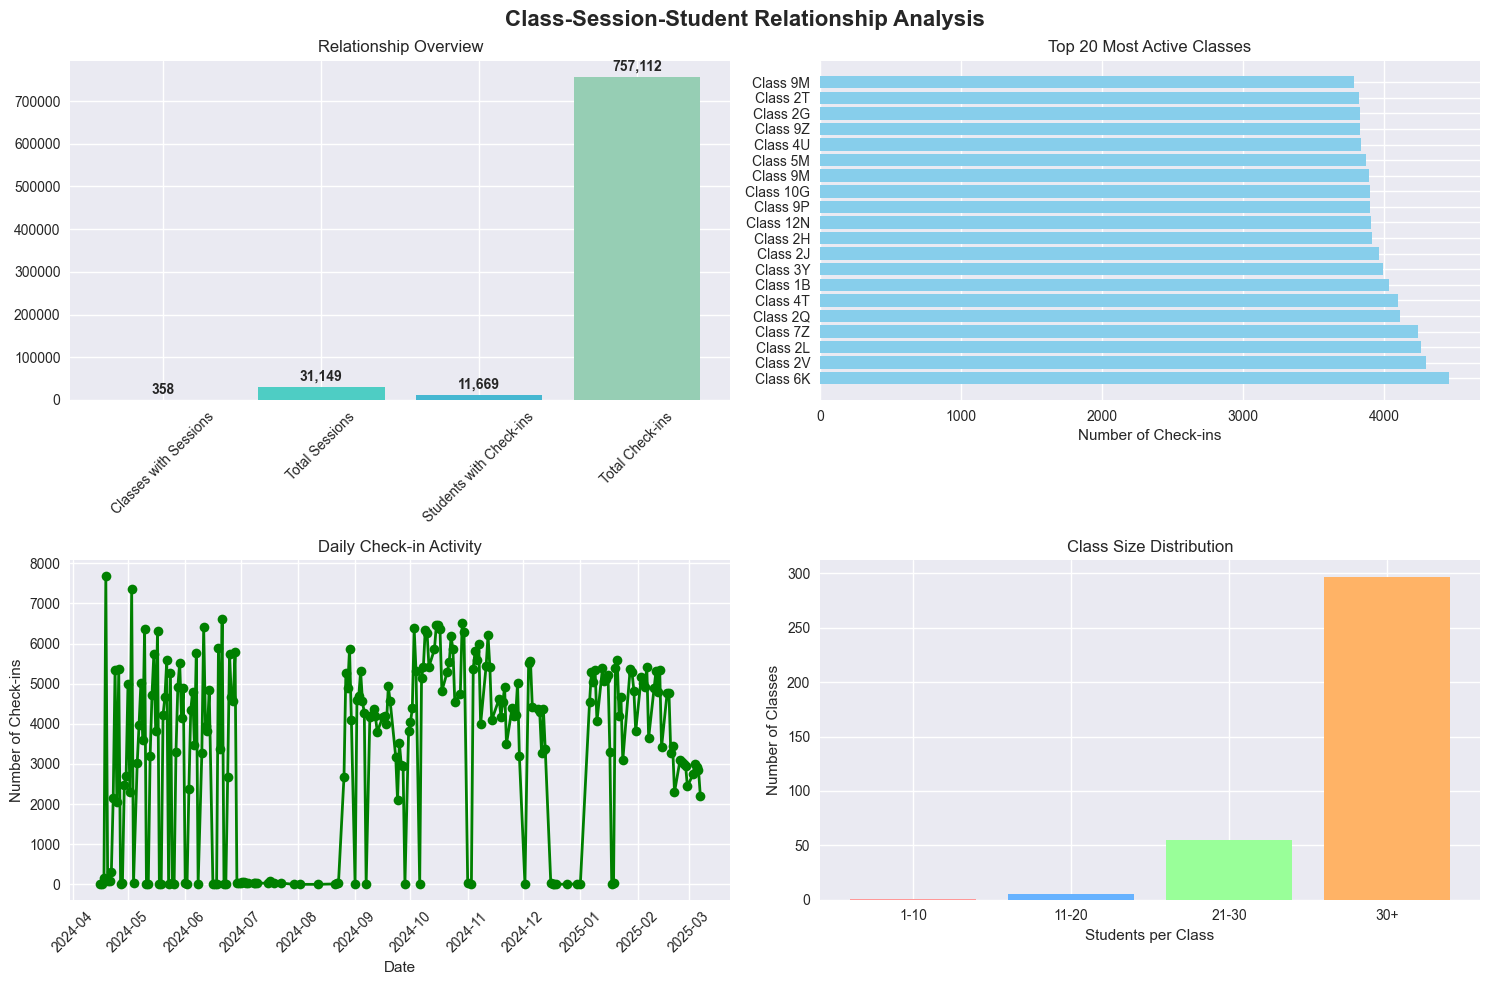

Relationship building completed successfully


In [16]:
# Build comprehensive relationships between classes, sessions, and students
print("Building class-session-student relationships...")

# Merge datasets to create complete relationship
complete_relationship = (
    df_sessions
    .merge(df_classes, on='Class ID', how='left')
    .merge(df_student_checkins, on='Check In Session ID', how='inner')
    .merge(df_students, left_on='Student ID', right_on='ID', how='left')
)

# Convert datetime column
complete_relationship['Opened Date Time'] = pd.to_datetime(complete_relationship['Opened Date Time'])

print(f"Complete relationship dataset: {complete_relationship.shape}")
print(f"Columns: {list(complete_relationship.columns)}")

# Create relationship summary visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Class-Session-Student Relationship Analysis', fontsize=16, fontweight='bold')

# Relationship summary
relationship_summary = {
    'Classes with Sessions': len(complete_relationship['Class ID'].unique()),
    'Total Sessions': len(complete_relationship['Check In Session ID'].unique()),
    'Students with Check-ins': len(complete_relationship['Student ID'].unique()),
    'Total Check-ins': len(complete_relationship)
}

bars = axes[0,0].bar(relationship_summary.keys(), relationship_summary.values(), 
                     color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[0,0].set_title('Relationship Overview')
axes[0,0].tick_params(axis='x', rotation=45)
for bar, value in zip(bars, relationship_summary.values()):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(relationship_summary.values())*0.01,
                   f'{value:,}', ha='center', va='bottom', fontweight='bold')

# Top 20 most active classes
top_classes = complete_relationship.groupby(['Class ID', 'Class Name']).size().sort_values(ascending=False).head(20)
axes[0,1].barh(range(len(top_classes)), top_classes.values, color='skyblue')
axes[0,1].set_yticks(range(len(top_classes)))
axes[0,1].set_yticklabels([name[:15] + '...' if len(name) > 15 else name for name in top_classes.index.get_level_values('Class Name')])
axes[0,1].set_title('Top 20 Most Active Classes')
axes[0,1].set_xlabel('Number of Check-ins')

# Daily activity pattern
daily_activity = complete_relationship.groupby(complete_relationship['Opened Date Time'].dt.date).size()
axes[1,0].plot(daily_activity.index, daily_activity.values, marker='o', linewidth=2, color='green')
axes[1,0].set_title('Daily Check-in Activity')
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('Number of Check-ins')
axes[1,0].tick_params(axis='x', rotation=45)

# Class size distribution
class_sizes = complete_relationship.groupby('Class ID')['Student ID'].nunique()
size_ranges = ['1-10', '11-20', '21-30', '30+']
size_counts = [
    len(class_sizes[(class_sizes >= 1) & (class_sizes <= 10)]),
    len(class_sizes[(class_sizes >= 11) & (class_sizes <= 20)]),
    len(class_sizes[(class_sizes >= 21) & (class_sizes <= 30)]),
    len(class_sizes[class_sizes > 30])
]
axes[1,1].bar(size_ranges, size_counts, color=['#FF9999', '#66B2FF', '#99FF99', '#FFB366'])
axes[1,1].set_title('Class Size Distribution')
axes[1,1].set_xlabel('Students per Class')
axes[1,1].set_ylabel('Number of Classes')

plt.tight_layout()
plt.show()

print("Relationship building completed successfully")


## Identify Top 100 Most Recent Classes


Identifying all classes with sessions...
Found 358 classes with sessions


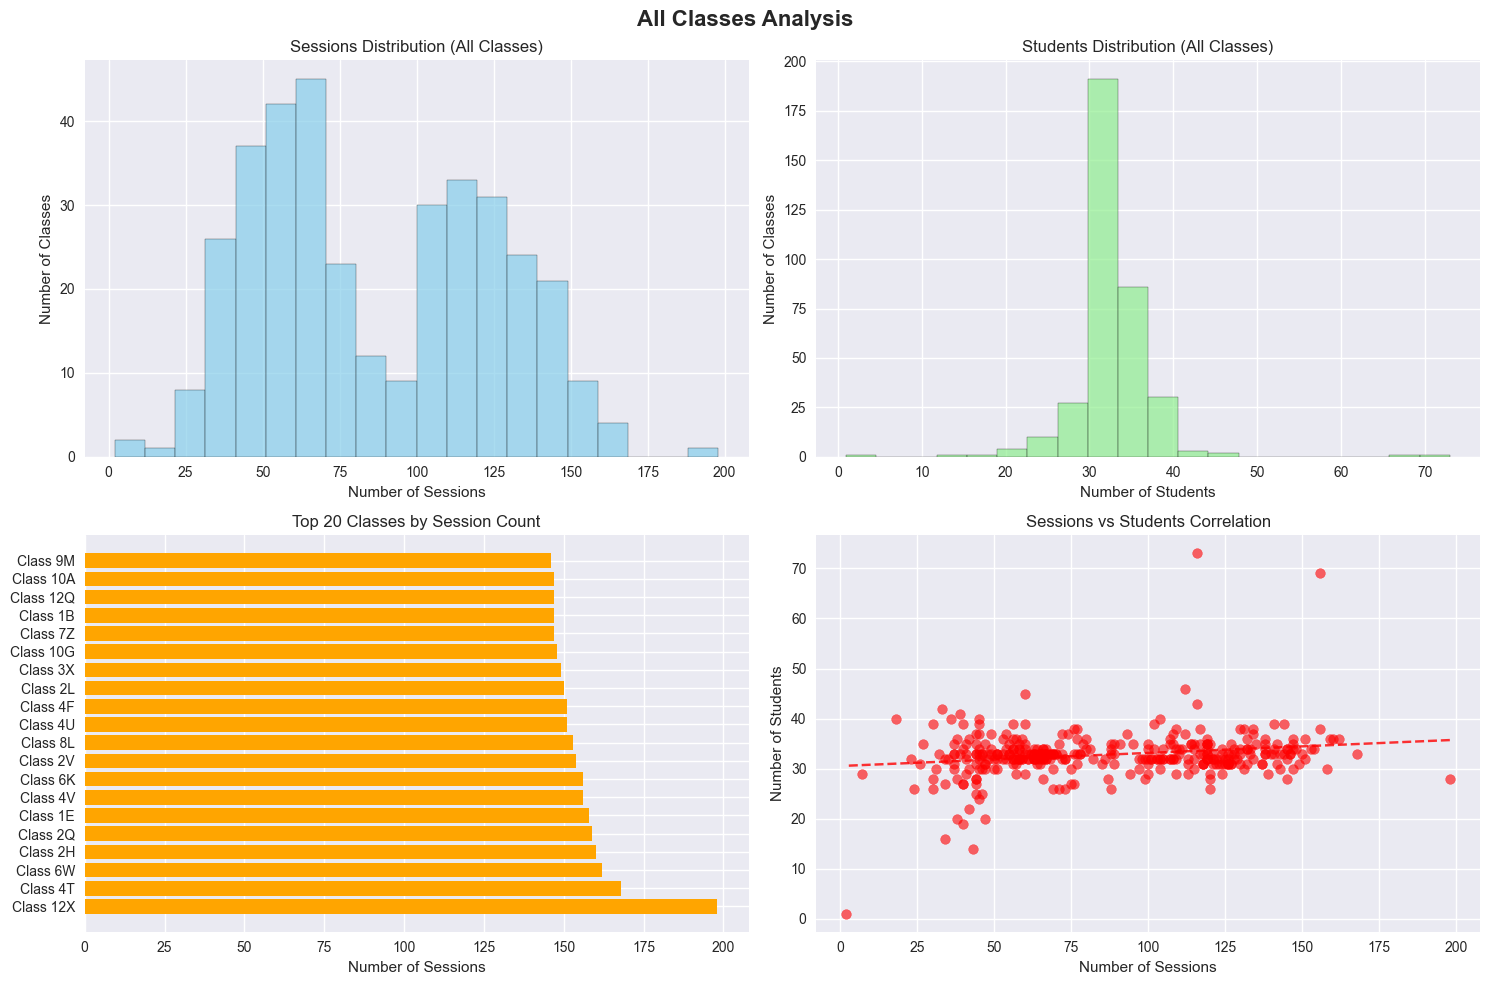


All Classes Summary:
Total sessions: 31149
Total students: 11740
Average sessions per class: 87.01
Average students per class: 32.79
All classes identification completed successfully


In [17]:
# Get ALL classes that have any sessions
print("Identifying all classes with sessions...")

# Get all classes with sessions (not limited to most recent date)
all_classes = complete_relationship.groupby(['Class ID', 'Class Name']).agg({
    'Check In Session ID': 'nunique',
    'Student ID': 'nunique',
    'Opened Date Time': 'max'
}).reset_index()

all_classes.columns = ['Class ID', 'Class Name', 'Sessions_Count', 'Students_Count', 'Last_Session']
all_classes = all_classes.sort_values('Sessions_Count', ascending=False)

# Use ALL classes (no cap)
top_100_classes = all_classes
print(f"Found {len(top_100_classes)} classes with sessions")

# Visualize all classes analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('All Classes Analysis', fontsize=16, fontweight='bold')

# Sessions distribution
axes[0,0].hist(top_100_classes['Sessions_Count'], bins=20, color='skyblue', alpha=0.7, edgecolor='black')
axes[0,0].set_title('Sessions Distribution (All Classes)')
axes[0,0].set_xlabel('Number of Sessions')
axes[0,0].set_ylabel('Number of Classes')

# Students distribution
axes[0,1].hist(top_100_classes['Students_Count'], bins=20, color='lightgreen', alpha=0.7, edgecolor='black')
axes[0,1].set_title('Students Distribution (All Classes)')
axes[0,1].set_xlabel('Number of Students')
axes[0,1].set_ylabel('Number of Classes')

# Top 20 classes by session count
top_20_by_sessions = top_100_classes.head(20)
axes[1,0].barh(range(len(top_20_by_sessions)), top_20_by_sessions['Sessions_Count'], color='orange')
axes[1,0].set_yticks(range(len(top_20_by_sessions)))
axes[1,0].set_yticklabels([name[:20] + '...' if len(name) > 20 else name for name in top_20_by_sessions['Class Name']])
axes[1,0].set_title('Top 20 Classes by Session Count')
axes[1,0].set_xlabel('Number of Sessions')

# Correlation between sessions and students
axes[1,1].scatter(top_100_classes['Sessions_Count'], top_100_classes['Students_Count'], alpha=0.6, color='red')
axes[1,1].set_title('Sessions vs Students Correlation')
axes[1,1].set_xlabel('Number of Sessions')
axes[1,1].set_ylabel('Number of Students')

if len(top_100_classes) > 1:
    z = np.polyfit(top_100_classes['Sessions_Count'], top_100_classes['Students_Count'], 1)
    p = np.poly1d(z)
    axes[1,1].plot(top_100_classes['Sessions_Count'], p(top_100_classes['Sessions_Count']), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

print(f"\nAll Classes Summary:")
print(f"Total sessions: {top_100_classes['Sessions_Count'].sum()}")
print(f"Total students: {top_100_classes['Students_Count'].sum()}")
print(f"Average sessions per class: {top_100_classes['Sessions_Count'].mean():.2f}")
print(f"Average students per class: {top_100_classes['Students_Count'].mean():.2f}")

print("All classes identification completed successfully")


## 7. Student Wellbeing Profiles
Individual student-level emotional profiling including wellbeing survey scores.
This section uses `wellbeingResponse.csv` in addition to check-in data.

In [18]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import json
from typing import Dict, List, Tuple
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

class FilteredStudentRecommendationAI:
    def __init__(self, filtered_checkins_df):
        """
        Initialize with filtered student check-ins DataFrame
        
        Parameters:
        filtered_checkins_df: DataFrame with columns:
            ['Check In Session ID', 'Student Check In ID', 'Student ID', 
             'Absencce', 'Emotion', 'Emotion Intensity Percentage', 'Tiredness', 
             'Request For Chat', 'Chat Cleared', 'Eating', 'Class ID', 
             'Class Name', 'Opened Date Time']
        """
        self.filtered_data = filtered_checkins_df.copy()
        self.wellbeing_data = None
        self.activities_data = None
        self.student_profiles = {}
        self.risk_students = []
        self.recommendations = {}
        self.intervention_mapping = {}
        
    def load_optional_data(self, wellbeing_responses_path=None, 
                          wellbeing_questions_path=None, 
                          activities_path=None):
        """
        Load optional wellbeing and activities data
        
        Parameters:
        wellbeing_responses_path: Path to wellbeingResponse.csv
        wellbeing_questions_path: Path to wellbeingQuestion.csv
        activities_path: Path to switches-summary.csv
        """
        try:
            # Load wellbeing responses
            if wellbeing_responses_path:
                wellbeing_resp = pd.read_csv(wellbeing_responses_path)
                wellbeing_resp = wellbeing_resp[wellbeing_resp['User Type'] == 'STUDENT']
                wellbeing_resp['Created At'] = pd.to_datetime(wellbeing_resp['Created At'], errors='coerce')
                
                # Load and merge with questions if available
                if wellbeing_questions_path:
                    wellbeing_q = pd.read_csv(wellbeing_questions_path)
                    self.wellbeing_data = wellbeing_resp.merge(
                        wellbeing_q, 
                        left_on='Wellbeing Question ID', 
                        right_on='id', 
                        how='left'
                    )
                else:
                    self.wellbeing_data = wellbeing_resp
                    
                print(f"✅ Loaded wellbeing data: {len(self.wellbeing_data)} records")
            
            # Load activities
            if activities_path:
                self.activities_data = pd.read_csv(activities_path)
                print(f"✅ Loaded activities data: {len(self.activities_data)} activities")
                
            return True
        except Exception as e:
            print(f"⚠️ Warning loading optional data: {e}")
            return False
    
    def create_student_profiles(self):
        """Create emotional profiles for filtered students"""
        try:
            # Clean and convert data types
            if 'Opened Date Time' in self.filtered_data.columns:
                self.filtered_data['Opened Date Time'] = pd.to_datetime(
                    self.filtered_data['Opened Date Time'], errors='coerce'
                )
            
            # Convert numeric columns
            if 'Emotion Intensity Percentage' in self.filtered_data.columns:
                self.filtered_data['Emotion Intensity Percentage'] = pd.to_numeric(
                    self.filtered_data['Emotion Intensity Percentage'], errors='coerce'
                )
            
            if 'Tiredness' in self.filtered_data.columns:
                self.filtered_data['Tiredness'] = pd.to_numeric(
                    self.filtered_data['Tiredness'], errors='coerce'
                )
            
            # Get unique students
            unique_students = self.filtered_data['Student ID'].dropna().unique()
            print(f"Processing {len(unique_students)} filtered students...")
            
            for student_id in tqdm(unique_students, desc="Creating profiles", unit="students"):
                student_data = self.filtered_data[self.filtered_data['Student ID'] == student_id]
                
                if student_data.empty:
                    continue
                
                # Get emotions
                emotions = student_data['Emotion'].dropna()
                emotion_mode = emotions.mode()
                dominant_emotion = emotion_mode.iloc[0] if len(emotion_mode) > 0 else 'Unknown'
                
                # Base profile from filtered check-in data
                profile = {
                    'student_id': student_id,
                    'class_id': student_data['Class ID'].iloc[0] if 'Class ID' in student_data.columns else None,
                    'class_name': student_data['Class Name'].iloc[0] if 'Class Name' in student_data.columns else None,
                    'total_checkins': len(student_data),
                    'emotions': {
                        'dominant_emotion': dominant_emotion,
                        'avg_intensity': float(student_data['Emotion Intensity Percentage'].mean()) if pd.notna(student_data['Emotion Intensity Percentage'].mean()) else None,
                        'emotion_distribution': emotions.value_counts().to_dict(),
                        'recent_emotions': list(emotions.tail(5))
                    },
                    'wellness_indicators': {
                        'avg_tiredness': float(student_data['Tiredness'].mean()) if pd.notna(student_data['Tiredness'].mean()) else None,
                        'chat_requests': int(student_data['Request For Chat'].notna().sum()),
                        'absence_rate': float(student_data['Absencce'].notna().sum() / len(student_data))
                    },
                    'wellbeing_scores': {},
                    'trend_analysis': self._analyze_trends(student_data),
                    'last_checkin': student_data['Opened Date Time'].max() if 'Opened Date Time' in student_data.columns else None
                }
                
                # Add wellbeing data if available
                if self.wellbeing_data is not None:
                    wellbeing_student = self.wellbeing_data[
                        self.wellbeing_data['User ID'] == student_id
                    ]
                    
                    if not wellbeing_student.empty and 'category' in wellbeing_student.columns:
                        for category in ['CONNECTEDNESS', 'SOCIAL_IDENTITY', 'ACADEMIC_ENGAGEMENT']:
                            category_data = wellbeing_student[wellbeing_student['category'] == category]
                            if not category_data.empty and 'Answer' in category_data.columns:
                                answers = pd.to_numeric(category_data['Answer'], errors='coerce').dropna()
                                if not answers.empty:
                                    profile['wellbeing_scores'][category] = float(answers.mean())
                
                self.student_profiles[student_id] = profile
            
            print(f"✅ Created profiles for {len(self.student_profiles)} students")
            return True
            
        except Exception as e:
            print(f"❌ Error creating profiles: {e}")
            import traceback
            traceback.print_exc()
            return False
    
    def _analyze_trends(self, student_data):
        """
        Analyze emotional trends for a student by loading their complete history
        from the original student check-in file in ONE function
        """
        try:
            # Get student ID from filtered data
            
            student_id = student_data['Student ID'].iloc[0]
            
            # Step 1: Try to load the ORIGINAL student check-in file
            original_checkin_files = 'datasets/studentCheckIn_cleaned.csv',
            
            
            student_history = None
            data_source = 'filtered_data_only'
            
            for filepath in original_checkin_files:
                try:
                    full_checkins = pd.read_csv(filepath)
                    
                    # Step 2: Filter for THIS specific student
                    student_history = full_checkins[full_checkins['Student ID'] == student_id].copy()
                    print(student_history)
                    if not student_history.empty:
                        print(f"✅ Loaded full history for student from: {filepath}")
                        data_source = 'full_original_history'
                        break
                except FileNotFoundError:
                    continue
                except Exception as e:
                    continue
            
            # Step 3: If no original file found, use filtered data
            if student_history is None or student_history.empty:
                student_history = student_data.copy()
                data_source = 'filtered_data_only'
            
            # Step 4: Find and convert the timestamp column
            timestamp_col = None
            for col in ['Created At', 'Opened Date Time', 'Timestamp', 'Date', 'created_at', 'opened_date_time']:
                if col in student_history.columns:
                    timestamp_col = col
                    break
            
            if timestamp_col is None:
                return {
                    'trend': 'insufficient_data',
                    'error': 'No timestamp column found',
                    'available_columns': list(student_history.columns)
                }
            
            # Step 5: Convert timestamp and sort chronologically
            student_history[timestamp_col] = pd.to_datetime(
                student_history[timestamp_col], errors='coerce'
            )
            student_history = student_history.sort_values(timestamp_col).dropna(subset=[timestamp_col])
            
            if len(student_history) < 2:
                return {
                    'trend': 'insufficient_data',
                    'total_historical_checkins': len(student_history)
                }
            
            # Step 6: Convert emotion intensity to numeric
            if 'Emotion Intensity Percentage' not in student_history.columns:
                return {'trend': 'insufficient_data', 'error': 'No emotion intensity column'}
            
            student_history['Emotion Intensity Percentage'] = pd.to_numeric(
                student_history['Emotion Intensity Percentage'], errors='coerce'
            )
            
            # Step 7: Extract all emotions and intensities chronologically
            all_emotions = student_history['Emotion'].dropna().tolist()
            intensities = student_history['Emotion Intensity Percentage'].dropna()
            
            if len(intensities) < 2:
                return {
                    'trend': 'insufficient_data',
                    'total_historical_checkins': len(student_history),
                    'emotions_tracked': len(all_emotions)
                }
            
            # Step 8: Calculate all trend metrics
            total_records = len(intensities)
            
            # Recent vs earlier comparison
            recent_window = max(3, int(total_records * 0.1))  # Last 10% or minimum 3
            recent_avg = float(intensities.tail(recent_window).mean())
            earlier_avg = float(intensities.head(recent_window).mean())
            
            # First half vs second half
            split_point = total_records // 2
            first_half_avg = float(intensities.iloc[:split_point].mean())
            second_half_avg = float(intensities.iloc[split_point:].mean())
            
            # Step 9: Determine overall trend
            trend = 'stable'
            if recent_avg > earlier_avg + 0.2:
                trend = 'improving'
            elif recent_avg < earlier_avg - 0.2:
                trend = 'declining'
            
            # Step 10: Calculate emotion transitions
            emotion_transitions = []
            for i in range(len(all_emotions) - 1):
                transition = f"{all_emotions[i]} → {all_emotions[i+1]}"
                emotion_transitions.append(transition)
            
            from collections import Counter
            transition_counts = Counter(emotion_transitions)
            top_transitions = transition_counts.most_common(5)
            
            # Step 11: Analyze temporal patterns (time of day, day of week)
            patterns = {}
            try:
                student_history['hour'] = student_history[timestamp_col].dt.hour
                student_history['day_of_week'] = student_history[timestamp_col].dt.day_name()
                student_history['week'] = student_history[timestamp_col].dt.isocalendar().week
                
                # Time of day patterns
                hourly_avg = student_history.groupby('hour')['Emotion Intensity Percentage'].mean()
                if not hourly_avg.empty:
                    patterns['best_time_of_day'] = f"{int(hourly_avg.idxmax())}:00"
                    patterns['worst_time_of_day'] = f"{int(hourly_avg.idxmin())}:00"
                
                # Day of week patterns
                daily_avg = student_history.groupby('day_of_week')['Emotion Intensity Percentage'].mean()
                if not daily_avg.empty:
                    patterns['best_day'] = daily_avg.idxmax()
                    patterns['worst_day'] = daily_avg.idxmin()
                
                # Weekly trends
                weekly_avg = student_history.groupby('week')['Emotion Intensity Percentage'].mean()
                if len(weekly_avg) >= 2:
                    recent_weeks = weekly_avg.tail(4).mean()
                    earlier_weeks = weekly_avg.head(4).mean()
                    patterns['recent_weeks_vs_earlier'] = {
                        'recent': float(recent_weeks),
                        'earlier': float(earlier_weeks),
                        'trend': 'improving' if recent_weeks > earlier_weeks else 'declining'
                    }
            except:
                patterns = {}
            
            # Step 12: Return comprehensive trend analysis
            return {
                'trend': trend,
                'total_historical_checkins': len(student_history),
                'emotions_tracked': len(all_emotions),
                'all_emotions_history': all_emotions,
                'recent_avg_intensity': recent_avg,
                'earlier_avg_intensity': earlier_avg,
                'first_half_avg_intensity': first_half_avg,
                'second_half_avg_intensity': second_half_avg,
                'overall_avg_intensity': float(intensities.mean()),
                'volatility': float(intensities.std()),
                'max_intensity': float(intensities.max()),
                'min_intensity': float(intensities.min()),
                'top_emotion_transitions': [f"{trans} ({count}x)" for trans, count in top_transitions],
                'temporal_patterns': patterns,
                'data_source': data_source
            }
                
        except Exception as e:
            print(f"⚠️ Trend analysis error: {e}")
            import traceback
            traceback.print_exc()
            return {'trend': 'insufficient_data', 'error': str(e)}

    def _analyze_trends_from_filtered(self, student_data):
        """Fallback method using only filtered data if full history unavailable"""
        try:
            if 'Opened Date Time' not in student_data.columns or len(student_data) < 2:
                return {'trend': 'insufficient_data'}
            
            student_data = student_data.sort_values('Opened Date Time')
            
            intensities = pd.to_numeric(
                student_data['Emotion Intensity Percentage'], 
                errors='coerce'
            ).dropna()
            
            if len(intensities) < 2:
                return {'trend': 'insufficient_data'}
            
            recent_avg = float(intensities.tail(3).mean())
            earlier_avg = float(intensities.head(3).mean())
            
            trend = 'stable'
            if recent_avg > earlier_avg + 0.2:
                trend = 'improving'
            elif recent_avg < earlier_avg - 0.2:
                trend = 'declining'
            
            all_emotions = student_data['Emotion'].dropna().tolist()
            
            return {
                'trend': trend,
                'recent_avg_intensity': recent_avg,
                'earlier_avg_intensity': earlier_avg,
                'volatility': float(intensities.std()),
                'total_historical_checkins': len(student_data),
                'emotions_tracked': len(all_emotions),
                'all_emotions_history': all_emotions,
                'data_source': 'filtered_only'
            }
        except Exception as e:
            return {'trend': 'insufficient_data'}


    def _analyze_temporal_patterns(self, student_history):
        """Analyze temporal patterns in emotional data"""
        try:
            if 'Opened Date Time' not in student_history.columns:
                return {}
            
            student_history = student_history.copy()
            
            # Extract time components
            student_history['hour'] = student_history['Opened Date Time'].dt.hour
            student_history['day_of_week'] = student_history['Opened Date Time'].dt.day_name()
            student_history['week'] = student_history['Opened Date Time'].dt.isocalendar().week
            
            # Convert intensity to numeric
            student_history['Emotion Intensity Percentage'] = pd.to_numeric(
                student_history['Emotion Intensity Percentage'], errors='coerce'
            )
            
            patterns = {}
            
            # Time of day patterns
            if 'hour' in student_history.columns:
                hourly_avg = student_history.groupby('hour')['Emotion Intensity Percentage'].mean()
                if not hourly_avg.empty:
                    best_hour = hourly_avg.idxmax()
                    worst_hour = hourly_avg.idxmin()
                    patterns['best_time_of_day'] = f"{int(best_hour)}:00"
                    patterns['worst_time_of_day'] = f"{int(worst_hour)}:00"
            
            # Day of week patterns
            if 'day_of_week' in student_history.columns:
                daily_avg = student_history.groupby('day_of_week')['Emotion Intensity Percentage'].mean()
                if not daily_avg.empty:
                    patterns['best_day'] = daily_avg.idxmax()
                    patterns['worst_day'] = daily_avg.idxmin()
            
            # Weekly trends
            if 'week' in student_history.columns:
                weekly_avg = student_history.groupby('week')['Emotion Intensity Percentage'].mean()
                if len(weekly_avg) >= 2:
                    recent_weeks = weekly_avg.tail(4).mean()
                    earlier_weeks = weekly_avg.head(4).mean()
                    patterns['recent_weeks_vs_earlier'] = {
                        'recent': float(recent_weeks),
                        'earlier': float(earlier_weeks),
                        'trend': 'improving' if recent_weeks > earlier_weeks else 'declining'
                    }
            
            return patterns
            
        except Exception as e:
            return {}


    # Enhanced display for trend analysis
    def display_student_trend_analysis(self, student_id):
        """Display detailed trend analysis for a student"""
        if student_id not in self.student_profiles:
            print(f"❌ Student ID {student_id} not found")
            return
        
        profile = self.student_profiles[student_id]
        trend = profile['trend_analysis']
        
        print("\n" + "="*80)
        print(f" 📈 TREND ANALYSIS: {student_id} ".center(80, "="))
        print("="*80)
        
        print(f"\n{'OVERVIEW':^80}")
        print("-"*80)
        print(f"   Overall Trend: {trend.get('trend', 'N/A').upper()}")
        print(f"   Total Historical Check-ins: {trend.get('total_historical_checkins', 'N/A')}")
        print(f"   Emotions Tracked: {trend.get('emotions_tracked', 'N/A')}")
        
        if trend.get('trend') != 'insufficient_data':
            print(f"\n{'INTENSITY METRICS':^80}")
            print("-"*80)
            print(f"   Overall Average: {trend.get('overall_avg_intensity', 'N/A'):.2f}")
            print(f"   Recent Average: {trend.get('recent_avg_intensity', 'N/A'):.2f}")
            print(f"   Previous Average: {trend.get('previous_avg_intensity', 'N/A'):.2f}")
            print(f"   First Half Average: {trend.get('first_half_avg_intensity', 'N/A'):.2f}")
            print(f"   Second Half Average: {trend.get('second_half_avg_intensity', 'N/A'):.2f}")
            print(f"   Volatility (Std Dev): {trend.get('volatility', 'N/A'):.2f}")
            print(f"   Range: {trend.get('min_intensity', 'N/A'):.2f} - {trend.get('max_intensity', 'N/A'):.2f}")
            
            # Emotion history
            if 'all_emotions_history' in trend and trend['all_emotions_history']:
                print(f"\n{'COMPLETE EMOTION HISTORY':^80}")
                print("-"*80)
                emotions_list = trend['all_emotions_history']
                
                # Show recent emotions
                print(f"\n   Most Recent 10 Emotions:")
                for i, emotion in enumerate(emotions_list[-10:], 1):
                    print(f"      {i}. {emotion}")
                
                # Emotion frequency
                from collections import Counter
                emotion_counts = Counter(emotions_list)
                print(f"\n   Emotion Frequency (All Time):")
                for emotion, count in emotion_counts.most_common():
                    percentage = (count / len(emotions_list)) * 100
                    bar_length = int(percentage / 2)
                    bar = "█" * bar_length
                    print(f"      {emotion:15} | {bar} {percentage:.1f}% ({count}x)")
            
            # Emotion transitions
            if 'top_emotion_transitions' in trend:
                print(f"\n{'TOP EMOTION TRANSITIONS':^80}")
                print("-"*80)
                for i, transition in enumerate(trend['top_emotion_transitions'], 1):
                    print(f"      {i}. {transition}")
            
            # Temporal patterns
            if 'temporal_patterns' in trend and trend['temporal_patterns']:
                patterns = trend['temporal_patterns']
                print(f"\n{'TEMPORAL PATTERNS':^80}")
                print("-"*80)
                
                if 'best_time_of_day' in patterns:
                    print(f"   Best Time of Day: {patterns['best_time_of_day']}")
                if 'worst_time_of_day' in patterns:
                    print(f"   Worst Time of Day: {patterns['worst_time_of_day']}")
                if 'best_day' in patterns:
                    print(f"   Best Day of Week: {patterns['best_day']}")
                if 'worst_day' in patterns:
                    print(f"   Worst Day of Week: {patterns['worst_day']}")
                
                if 'recent_weeks_vs_earlier' in patterns:
                    weekly = patterns['recent_weeks_vs_earlier']
                    print(f"\n   Weekly Trend:")
                    print(f"      Recent Weeks Average: {weekly['recent']:.2f}")
                    print(f"      Earlier Weeks Average: {weekly['earlier']:.2f}")
                    print(f"      Direction: {weekly['trend'].upper()}")
        
        print("\n" + "="*80 + "\n")       
    
    def identify_risk_students(self):
        """Identify at-risk students from filtered population"""
        try:
            risk_students = []
            
            for student_id, profile in tqdm(self.student_profiles.items(), 
                                          desc="Identifying risks", unit="students"):
                risk_score = 0
                risk_factors = []
                
                # Low emotional intensity
                avg_intensity = profile['emotions']['avg_intensity']
                if pd.notna(avg_intensity) and avg_intensity < 0.3:
                    risk_score += 3
                    risk_factors.append('Low emotional intensity')
                
                # Negative dominant emotions
                dominant_emotion = profile['emotions']['dominant_emotion']
                if dominant_emotion in ['SAD', 'ANGRY', 'ANXIOUS', 'FRUSTRATED']:
                    risk_score += 2
                    risk_factors.append(f'Predominantly {dominant_emotion.lower()}')
                
                # High tiredness
                avg_tiredness = profile['wellness_indicators']['avg_tiredness']
                if pd.notna(avg_tiredness) and avg_tiredness >= 4:
                    risk_score += 2
                    risk_factors.append('High tiredness levels')
                
                # Multiple chat requests
                if profile['wellness_indicators']['chat_requests'] > 2:
                    risk_score += 2
                    risk_factors.append('Multiple chat requests')
                
                # High absence rate
                if profile['wellness_indicators']['absence_rate'] > 0.3:
                    risk_score += 1
                    risk_factors.append('High absence rate')
                
                # Declining trend
                if profile['trend_analysis']['trend'] == 'declining':
                    risk_score += 2
                    risk_factors.append('Declining emotional trend')
                
                # Low wellbeing scores
                for category, score in profile['wellbeing_scores'].items():
                    if pd.notna(score) and score <= 2:
                        risk_score += 1
                        risk_factors.append(f'Low {category.lower().replace("_", " ")} score')
                
                # Classify risk level
                risk_level = 'Low'
                if risk_score >= 6:
                    risk_level = 'High'
                elif risk_score >= 3:
                    risk_level = 'Medium'
                
                if risk_score > 0:
                    risk_students.append({
                        'student_id': student_id,
                        'class_name': profile['class_name'],
                        'risk_score': risk_score,
                        'risk_level': risk_level,
                        'risk_factors': risk_factors,
                        'priority': 'Immediate' if risk_score >= 6 else 'Monitor'
                    })
            
            self.risk_students = sorted(risk_students, key=lambda x: x['risk_score'], reverse=True)
            print(f"✅ Identified {len(risk_students)} at-risk students")
            return True
            
        except Exception as e:
            print(f"❌ Error identifying risks: {e}")
            return False
    
    def load_intervention_mapping(self):
        """Create intervention mapping from activities data"""
        try:
            if self.activities_data is None:
                print("⚠️ No activities data loaded - using default interventions")
                self._create_default_interventions()
                return True
            
            intervention_mapping = {}
            
            for _, activity in tqdm(self.activities_data.iterrows(), 
                                   desc="Mapping interventions", 
                                   total=len(self.activities_data)):
                emotions = str(activity.get('Emotions', '')).lower()
                
                emotion_targets = []
                if 'sad' in emotions:
                    emotion_targets.extend(['SAD', 'DOWN'])
                if 'happy' in emotions:
                    emotion_targets.extend(['NEUTRAL', 'BORED'])
                if 'excited' in emotions:
                    emotion_targets.extend(['TIRED'])
                if 'angry' in emotions:
                    emotion_targets.extend(['ANGRY', 'FRUSTRATED'])
                if 'anxious' in emotions:
                    emotion_targets.extend(['ANXIOUS', 'WORRIED'])
                
                activity_info = {
                    'title': activity.get('Title', ''),
                    'summary': activity.get('Summary', ''),
                    'duration': activity.get('Duration', ''),
                    'levels': str(activity.get('Levels', '')),
                    'categories': activity.get('Categories', ''),
                    'has_lesson_plan': activity.get('Has Lesson Plan', 'No') == 'Yes'
                }
                
                for emotion in emotion_targets:
                    if emotion not in intervention_mapping:
                        intervention_mapping[emotion] = []
                    intervention_mapping[emotion].append(activity_info)
            
            self.intervention_mapping = intervention_mapping
            print(f"✅ Created intervention mapping for {len(intervention_mapping)} emotion types")
            return True
            
        except Exception as e:
            print(f"❌ Error mapping interventions: {e}")
            self._create_default_interventions()
            return False
    
    def _create_default_interventions(self):
        """Create default interventions if activities data not available"""
        self.intervention_mapping = {
            'SAD': [
                {'title': 'Mood Boost Activity', 'summary': 'Engaging group activity', 
                 'duration': '10-15 min', 'reason': 'Helps lift mood'},
            ],
            'ANGRY': [
                {'title': 'Calming Exercise', 'summary': 'Breathing and relaxation', 
                 'duration': '5-10 min', 'reason': 'Helps manage anger'},
            ],
            'ANXIOUS': [
                {'title': 'Mindfulness Practice', 'summary': 'Grounding techniques', 
                 'duration': '5-10 min', 'reason': 'Reduces anxiety'},
            ],
            'TIRED': [
                {'title': 'Energizing Break', 'summary': 'Movement and stretching', 
                 'duration': '5 min', 'reason': 'Increases energy'},
            ]
        }
    
    def generate_recommendations(self):
        """Generate recommendations for filtered students"""
        try:
            recommendations = {}
            
            for student_id, profile in tqdm(self.student_profiles.items(), 
                                          desc="Generating recommendations", 
                                          unit="students"):
                # Find risk info
                risk_student = next((rs for rs in self.risk_students 
                                   if rs['student_id'] == student_id), None)
                
                rec = {
                    'student_id': student_id,
                    'class_name': profile['class_name'],
                    'risk_level': risk_student['risk_level'] if risk_student else 'Low',
                    'immediate_actions': [],
                    'suggested_activities': [],
                    'monitoring_notes': [],
                    'explanation': ''
                }
                
                # Immediate actions for at-risk students
                if risk_student:
                    rec['immediate_actions'] = self._get_immediate_actions(risk_student)
                
                # Activity recommendations
                dominant_emotion = profile['emotions']['dominant_emotion']
                rec['suggested_activities'] = self._get_activity_recommendations(
                    dominant_emotion, profile
                )
                
                # Monitoring notes
                rec['monitoring_notes'] = self._generate_monitoring_notes(profile)
                
                # Explanation
                rec['explanation'] = self._create_explanation(profile, risk_student)
                
                recommendations[student_id] = rec
            
            self.recommendations = recommendations
            print(f"✅ Generated recommendations for {len(recommendations)} students")
            return True
            
        except Exception as e:
            print(f"❌ Error generating recommendations: {e}")
            return False
    
    def _get_immediate_actions(self, risk_student):
        """Get immediate actions for at-risk students"""
        actions = []
        
        if risk_student['risk_level'] == 'High':
            actions.append("🚨 Consider immediate one-on-one check-in")
            actions.append("📞 Alert school counselor if available")
        
        for factor in risk_student['risk_factors']:
            if 'chat request' in factor.lower():
                actions.append("💬 Student has requested to chat - prioritize connection")
            elif 'tiredness' in factor.lower():
                actions.append("😴 Check if student needs break or rest time")
            elif 'declining' in factor.lower():
                actions.append("📊 Monitor closely over next few days")
            elif 'absence' in factor.lower():
                actions.append("📅 Follow up on attendance patterns")
        
        return actions[:5]  # Limit to top 5 actions
    
    def _get_activity_recommendations(self, emotion, profile):
        """Get activity recommendations based on emotion"""
        activities = []
        
        # Get mapped activities for emotion
        if emotion in self.intervention_mapping:
            for activity in self.intervention_mapping[emotion][:3]:
                activities.append({
                    'title': activity['title'],
                    'summary': activity['summary'],
                    'duration': activity.get('duration', 'Flexible'),
                    'reason': f"Helps address {emotion.lower()} feelings"
                })
        
        # Add wellbeing-specific activities
        for category, score in profile['wellbeing_scores'].items():
            if pd.notna(score) and score <= 2:
                if category == 'CONNECTEDNESS':
                    activities.append({
                        'title': 'Group Connection Activity',
                        'summary': 'Facilitate peer interaction and bonding',
                        'duration': '15-20 min',
                        'reason': f'Low {category.lower()} score detected'
                    })
                elif category == 'ACADEMIC_ENGAGEMENT':
                    activities.append({
                        'title': 'Interactive Learning Game',
                        'summary': 'Engaging educational activity',
                        'duration': '15-20 min',
                        'reason': f'Low {category.lower()} score detected'
                    })
        
        return activities[:5]
    
    def _generate_monitoring_notes(self, profile):
        """Generate monitoring notes"""
        notes = []
        
        # Recent emotional pattern
        recent = profile['emotions']['recent_emotions']
        if recent:
            notes.append(f"📈 Recent emotions: {' → '.join(recent[-3:])}")
        
        # Tiredness
        avg_tiredness = profile['wellness_indicators']['avg_tiredness']
        if pd.notna(avg_tiredness):
            if avg_tiredness >= 4:
                notes.append(f"😴 High tiredness (avg: {avg_tiredness:.1f}/5)")
            elif avg_tiredness <= 2:
                notes.append(f"⚡ Generally energetic (avg: {avg_tiredness:.1f}/5)")
        
        # Trend
        trend = profile['trend_analysis']['trend']
        if trend == 'improving':
            notes.append("📈 Emotional wellbeing trending upward ✅")
        elif trend == 'declining':
            notes.append("📉 Emotional wellbeing trending downward - monitor closely")
        
        # Chat requests
        if profile['wellness_indicators']['chat_requests'] > 0:
            notes.append(f"💬 {profile['wellness_indicators']['chat_requests']} chat request(s)")
        
        return notes
    
    def _create_explanation(self, profile, risk_student):
        """Create AI explanation"""
        explanation = "🤖 AI Analysis: "
        
        dominant_emotion = profile['emotions']['dominant_emotion']
        avg_intensity = profile['emotions']['avg_intensity']
        
        explanation += f"Student's dominant emotion is {dominant_emotion}"
        
        if pd.notna(avg_intensity):
            if avg_intensity < 0.3:
                explanation += " with low intensity, suggesting possible emotional challenges. "
            elif avg_intensity > 0.7:
                explanation += " with high intensity, indicating strong emotional engagement. "
            else:
                explanation += " with moderate intensity. "
        
        if risk_student:
            explanation += f"⚠️ Risk level: {risk_student['risk_level']} due to: {', '.join(risk_student['risk_factors'][:2])}. "
        
        trend = profile['trend_analysis']['trend']
        if trend == 'declining':
            explanation += "📉 Recent trend shows decline - early intervention recommended."
        elif trend == 'improving':
            explanation += "📈 Positive trend detected - continue current support."
        
        return explanation
    
    def generate_class_dashboard(self):
        """Generate dashboard for the filtered class/group"""
        try:
            # Get unique classes
            classes = {}
            for student_id, profile in self.student_profiles.items():
                class_name = profile.get('class_name', 'Unknown')
                if class_name not in classes:
                    classes[class_name] = []
                classes[class_name].append(student_id)
            
            dashboard = {
                'overview': {
                    'total_students': len(self.student_profiles),
                    'classes': len(classes),
                    'high_risk_count': len([r for r in self.risk_students if r['risk_level'] == 'High']),
                    'medium_risk_count': len([r for r in self.risk_students if r['risk_level'] == 'Medium']),
                    'last_updated': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
                },
                'priority_students': [
                    {
                        'student_id': r['student_id'],
                        'class_name': r['class_name'],
                        'risk_level': r['risk_level'],
                        'priority': r['priority'],
                        'key_concerns': r['risk_factors'][:3],
                        'recommendations': self.recommendations.get(r['student_id'], {}).get('immediate_actions', [])[:3]
                    }
                    for r in self.risk_students[:15]
                ],
                'class_breakdown': self._generate_class_breakdown(classes),
                'emotional_summary': self._generate_emotional_summary(),
                'recommended_activities': self._get_top_activities()
            }
            
            return dashboard
            
        except Exception as e:
            print(f"❌ Error generating dashboard: {e}")
            return {}
    
    def _generate_class_breakdown(self, classes):
        """Generate breakdown by class"""
        breakdown = []
        for class_name, student_ids in classes.items():
            class_profiles = [self.student_profiles[sid] for sid in student_ids]
            
            emotions = []
            intensities = []
            for profile in class_profiles:
                if profile['emotions']['dominant_emotion'] != 'Unknown':
                    emotions.append(profile['emotions']['dominant_emotion'])
                if pd.notna(profile['emotions']['avg_intensity']):
                    intensities.append(profile['emotions']['avg_intensity'])
            
            class_risks = [r for r in self.risk_students if r['student_id'] in student_ids]
            
            breakdown.append({
                'class_name': class_name,
                'total_students': len(student_ids),
                'high_risk': len([r for r in class_risks if r['risk_level'] == 'High']),
                'medium_risk': len([r for r in class_risks if r['risk_level'] == 'Medium']),
                'dominant_emotion': max(set(emotions), key=emotions.count) if emotions else 'Unknown',
                'avg_intensity': np.mean(intensities) if intensities else 0
            })
        
        return breakdown
    
    def _generate_emotional_summary(self):
        """Generate overall emotional summary"""
        emotions = []
        intensities = []
        
        for profile in self.student_profiles.values():
            if profile['emotions']['dominant_emotion'] != 'Unknown':
                emotions.append(profile['emotions']['dominant_emotion'])
            if pd.notna(profile['emotions']['avg_intensity']):
                intensities.append(profile['emotions']['avg_intensity'])
        
        return {
            'dominant_emotion': max(set(emotions), key=emotions.count) if emotions else 'Unknown',
            'avg_intensity': np.mean(intensities) if intensities else 0,
            'emotion_distribution': {e: emotions.count(e) for e in set(emotions)}
        }
    
    def _get_top_activities(self):
        """Get most recommended activities"""
        activity_counts = {}
        
        for rec in self.recommendations.values():
            for activity in rec.get('suggested_activities', []):
                title = activity['title']
                if title not in activity_counts:
                    activity_counts[title] = {
                        'count': 0,
                        'summary': activity['summary'],
                        'duration': activity.get('duration', 'Flexible')
                    }
                activity_counts[title]['count'] += 1
        
        top = sorted(activity_counts.items(), key=lambda x: x[1]['count'], reverse=True)
        
        return [
            {
                'title': title,
                'recommended_for': data['count'],
                'summary': data['summary'],
                'duration': data['duration']
            }
            for title, data in top[:5]
        ]
    
    def display_dashboard(self, dashboard):
        """Display dashboard in readable format"""
        print("\n" + "="*60)
        print("🎯 FILTERED STUDENTS DASHBOARD")
        print("="*60)
        
        overview = dashboard['overview']
        print(f"\n📊 OVERVIEW:")
        print(f"   Total Students: {overview['total_students']}")
        print(f"   Classes: {overview['classes']}")
        print(f"   🔴 High Risk: {overview['high_risk_count']}")
        print(f"   🟡 Medium Risk: {overview['medium_risk_count']}")
        print(f"   Last Updated: {overview['last_updated']}")
        
        print(f"\n🚨 PRIORITY STUDENTS:")
        for student in dashboard['priority_students'][:10]:
            print(f"\n   Student ID: {student['student_id']}")
            print(f"   Class: {student['class_name']}")
            print(f"   Risk: {student['risk_level']} ({student['priority']})")
            print(f"   Concerns: {', '.join(student['key_concerns'])}")
            if student['recommendations']:
                print(f"   Actions: {student['recommendations'][0]}")
        
        print(f"\n📚 CLASS BREAKDOWN:")
        for class_info in dashboard['class_breakdown']:
            print(f"\n   {class_info['class_name']}:")
            print(f"      Students: {class_info['total_students']}")
            print(f"      High Risk: {class_info['high_risk']} | Medium Risk: {class_info['medium_risk']}")
            print(f"      Dominant Emotion: {class_info['dominant_emotion']}")
            print(f"      Avg Intensity: {class_info['avg_intensity']:.2f}")
        
        print(f"\n😊 EMOTIONAL SUMMARY:")
        summary = dashboard['emotional_summary']
        print(f"   Dominant Emotion: {summary['dominant_emotion']}")
        print(f"   Average Intensity: {summary['avg_intensity']:.2f}")
        
        print(f"\n🎯 TOP RECOMMENDED ACTIVITIES:")
        for activity in dashboard['recommended_activities'][:5]:
            print(f"   • {activity['title']} (for {activity['recommended_for']} students)")
            print(f"     {activity['summary']} | Duration: {activity['duration']}")
    
    def export_results(self, filename='filtered_recommendations.json'):
        """Export results to JSON"""
        try:
            results = {
                'student_profiles': {k: {**v, 'last_checkin': str(v['last_checkin'])} 
                                   for k, v in self.student_profiles.items()},
                'risk_students': self.risk_students,
                'recommendations': self.recommendations,
                'dashboard': self.generate_class_dashboard(),
                'export_timestamp': datetime.now().isoformat()
            }
            
            with open(filename, 'w') as f:
                json.dump(results, f, indent=2, default=str)
            
            print(f"\n✅ Results exported to {filename}")
            return True
        except Exception as e:
            print(f"❌ Error exporting: {e}")
            return False
    
    def run_complete_analysis(self):
        """Run complete analysis pipeline"""
        print("\n" + "="*60)
        print("🚀 STARTING FILTERED STUDENT ANALYSIS")
        print("="*60)
        
        steps = [
            ("Creating student profiles", self.create_student_profiles),
            ("Identifying risk students", self.identify_risk_students),
            ("Loading interventions", self.load_intervention_mapping),
            ("Generating recommendations", self.generate_recommendations)
        ]
        
        for step_name, step_func in steps:
            print(f"\n📌 {step_name}...")
            if not step_func():
                print(f"❌ Failed at: {step_name}")
                return False
        
        print("\n" + "="*60)
        print("✅ ANALYSIS COMPLETE!")
        print("="*60)
        
        dashboard = self.generate_class_dashboard()
        self.display_dashboard(dashboard)
        
        return True

# Example usage:

# Load your filtered data
ai = FilteredStudentRecommendationAI(result)

# Optional: Load wellbeing and activities data
ai.load_optional_data(
    wellbeing_responses_path='./datasets/wellbeingResponse.csv',
    wellbeing_questions_path='./datasets/wellbeingQuestion.csv',
    activities_path='./datasets/switches-summary.csv'
)

# Run analysis
ai.run_complete_analysis()
ai.export_results('filtered_recommendations.json')



✅ Loaded wellbeing data: 465686 records
✅ Loaded activities data: 107 activities

🚀 STARTING FILTERED STUDENT ANALYSIS

📌 Creating student profiles...
Processing 30 filtered students...


Creating profiles:   3%|▎         | 1/30 [00:02<01:19,  2.74s/students]

                       Check In Session ID  \
29    178d49ba-75f4-4bb9-a78a-55bca3321773   
51    4cdec2e2-23d1-483b-b911-530d60c95acc   
67    8e15d01c-2a00-4a42-b43e-a28599001c69   
71    ca73e7e7-7137-4fc0-8ef7-c42592dea7cf   
107   a04bedbc-2e8a-449c-9447-fba5b8a52205   
...                                    ...   
3040  01fd4d76-d271-416d-9e7c-c500f28f7461   
3066  0690ad88-253b-45a5-84e3-ab32ab11a68b   
3115  20563d37-6657-412e-991c-fedfb66a7167   
3140  664bcf21-d339-4561-b0e3-3c71fa2742e5   
3154  a05780fc-2ff3-424e-b1bb-dddd20e748a3   

                       Student Check In ID  \
29    b2b64473-cd66-482d-a168-e2601363fcfa   
51    159d5910-95d7-458e-9faa-feffe7bd4b83   
67    7979de37-b5e8-4397-8604-0ca195513e6b   
71    e04ea446-cbf9-4501-86d6-cd906726a721   
107   32436032-56e0-43fd-a320-2801660e4a16   
...                                    ...   
3040  65d1d909-4cbc-40bd-8731-b16383877462   
3066  b4cdb9f2-af42-4f5c-a20a-f34274a8f33c   
3115  2e69c941-6bfb-47a5-affa-c02

Creating profiles:   7%|▋         | 2/30 [00:05<01:16,  2.75s/students]

                       Check In Session ID  \
3     178d49ba-75f4-4bb9-a78a-55bca3321773   
45    4cdec2e2-23d1-483b-b911-530d60c95acc   
76    ca73e7e7-7137-4fc0-8ef7-c42592dea7cf   
109   a04bedbc-2e8a-449c-9447-fba5b8a52205   
139   f4de17c4-c123-4305-a910-a5d316d8521c   
...                                    ...   
3049  01fd4d76-d271-416d-9e7c-c500f28f7461   
3075  0690ad88-253b-45a5-84e3-ab32ab11a68b   
3107  20563d37-6657-412e-991c-fedfb66a7167   
3143  664bcf21-d339-4561-b0e3-3c71fa2742e5   
3155  a05780fc-2ff3-424e-b1bb-dddd20e748a3   

                       Student Check In ID  \
3     d71d5fb3-f0f7-408f-852c-a8300f666574   
45    729d7403-bb9f-404b-986c-5c6c79df9c3f   
76    15337940-49d3-4643-b1cb-2e48e8616b0a   
109   61567667-7d96-42a4-9853-2182b75e7102   
139   9f19cde0-64e0-41b7-88f3-4381793a9f7c   
...                                    ...   
3049  ebfd1f27-c6fe-415e-9508-48e5f04ebced   
3075  c9ec0747-1bc5-44ca-a924-75fb190b3a7a   
3107  399e6b1f-3a5c-4eaa-b1a8-81c

...

Mapping interventions: 100%|██████████| 107/107 [00:00<00:00, 5451.32it/s]


✅ Created intervention mapping for 9 emotion types

📌 Generating recommendations...


Generating recommendations: 100%|██████████| 30/30 [00:00<00:00, 16233.92students/s]

✅ Generated recommendations for 30 students

✅ ANALYSIS COMPLETE!

🎯 FILTERED STUDENTS DASHBOARD

📊 OVERVIEW:
   Total Students: 30
   Classes: 1
   🔴 High Risk: 0
   🟡 Medium Risk: 19
   Last Updated: 2026-03-20 14:56:46

🚨 PRIORITY STUDENTS:

   Student ID: 20390f94-f3fe-4d89-a8f9-8bdb2dbe98ae
   Class: Class 11A
   Risk: Medium (Monitor)
   Concerns: Predominantly angry, High tiredness levels, High absence rate
   Actions: 😴 Check if student needs break or rest time

   Student ID: 824fbd77-fda6-4f5b-b613-7ba298691699
   Class: Class 11A
   Risk: Medium (Monitor)
   Concerns: High tiredness levels, High absence rate
   Actions: 😴 Check if student needs break or rest time

   Student ID: 3173234a-34c3-441d-8b72-f75b188abeff
   Class: Class 11A
   Risk: Medium (Monitor)
   Concerns: High tiredness levels, High absence rate
   Actions: 😴 Check if student needs break or rest time

   Student ID: dbed2e8e-3433-437b-84c3-78249a5537e3
   Class: Class 11A
   Risk: Medium (Monitor)
   Concer

True

In [19]:
import pandas as pd
from tqdm import tqdm
import os

# ----------------------------
# Helper: Load & compute wellbeing scores
# ----------------------------
def load_and_compute_wellbeing_scores(well_q_path='wellbeingQuestion.csv',
                                       well_r_path='wellbeingResponse.csv',
                                       student_ids=None):
    """
    Load wellbeingQuestion and wellbeingResponse files (if present) and compute
    per-student aggregated wellbeing features.

    Returns a DataFrame indexed by 'Student ID' with columns prefixed by 'Wellbeing_'.
    If files are missing or unparseable, returns an empty DataFrame.
    """

    if not os.path.exists(well_q_path) or not os.path.exists(well_r_path):
        print("Wellbeing files not found; skipping wellbeing merge.")
        return pd.DataFrame()

    try:
        qdf = pd.read_csv(well_q_path)
        rdf = pd.read_csv(well_r_path)
    except Exception as e:
        print(f"Failed to read wellbeing CSVs: {e}")
        return pd.DataFrame()

    # Standardize column names to lower-case for robust matching
    qcols = {c.lower(): c for c in qdf.columns}
    rcols = {c.lower(): c for c in rdf.columns}

    # Guess column names in question file: id and label
    q_id_col = qcols.get('question id') or qcols.get('id') or qcols.get('questionid') or qcols.get('question_id') or None
    q_label_col = qcols.get('label') or qcols.get('question') or qcols.get('text') or None

    # Guess columns in response file: student id, question id, answer
    r_student_col = rcols.get('student id') or rcols.get('studentid') or rcols.get('student_id') or None
    r_qid_col = rcols.get('question id') or rcols.get('questionid') or rcols.get('question_id') or rcols.get('question') or None
    r_answer_col = rcols.get('answer') or rcols.get('response') or rcols.get('value') or None

    # If required columns not found, try a best-effort approach
    if r_student_col is None or r_qid_col is None or r_answer_col is None:
        # Show what we have and bail out if too unclear
        print("Could not find expected columns in wellbeingResponse.csv. Columns found:", list(rdf.columns))
        return pd.DataFrame()

    # Use the original column names
    r_student_col = rcols[r_student_col.lower()]
    r_qid_col = rcols[r_qid_col.lower()]
    r_answer_col = rcols[r_answer_col.lower()]

    # If question labels available, map question id -> label
    qid_to_label = {}
    if q_id_col is not None:
        q_id_col = qcols[q_id_col.lower()]
        if q_label_col is not None:
            q_label_col = qcols[q_label_col.lower()]
            for _, row in qdf.iterrows():
                qid_to_label[row[q_id_col]] = str(row[q_label_col])
        else:
            # use id as label if no label col
            for _, row in qdf.iterrows():
                qid_to_label[row[q_id_col]] = str(row[q_id_col])
    else:
        # no question file; we'll use question ids as-is later
        qid_to_label = None

    # Filter response dataframe to only students we care about (if provided)
    if student_ids is not None:
        rdf = rdf[rdf[r_student_col].isin(student_ids)]

    # Pivot responses: rows = Student ID, cols = Question ID (or label), values = Answer (first)
    try:
        pivot = rdf.pivot_table(index=r_student_col, columns=r_qid_col, values=r_answer_col, aggfunc='first')
    except Exception as e:
        print("Pivot failed for wellbeing responses:", e)
        return pd.DataFrame()

    # Rename columns to Wellbeing_<label or id>
    new_cols = {}
    for col in pivot.columns:
        label = None
        if qid_to_label is not None:
            # try mapping
            label = qid_to_label.get(col, None)
        label_or_id = label if label is not None else str(col)
        safe_label = f"Wellbeing_{label_or_id}".replace(' ', '_')
        new_cols[col] = safe_label

    pivot = pivot.rename(columns=new_cols)
    pivot.index.name = 'Student ID'
    pivot = pivot.reset_index()

    # Convert response values to numeric where possible
    for c in pivot.columns:
        if c == 'Student ID':
            continue
        pivot[c] = pd.to_numeric(pivot[c], errors='coerce')

    # Compute an aggregated wellbeing score per student (mean of wellbeing columns)
    wellbeing_cols = [c for c in pivot.columns if c != 'Student ID']
    if len(wellbeing_cols) == 0:
        print("No wellbeing response columns found after pivot.")
        return pd.DataFrame()

    pivot['Wellbeing_OverallScore'] = pivot[wellbeing_cols].mean(axis=1, skipna=True)

    # Return DataFrame indexed by Student ID
    pivot = pivot.set_index('Student ID')
    return pivot  # contains Wellbeing_* columns and Wellbeing_OverallScore

# ----------------------------
# Trend analysis (robust)
# ----------------------------
def _analyze_emotional_trends(student_data):
    """
    Robust trend analysis for a student's Emotion Intensity Percentage over time.
    Accepts a DataFrame (subset for a student).
    Returns dict with trend, recent_avg_intensity, earlier_avg_intensity, volatility.
    """
    try:
        if student_data.empty:
            return {'trend': 'insufficient_data'}

        # choose timestamp column
        time_col = None
        if 'Created At' in student_data.columns:
            time_col = 'Created At'
        elif 'Opened Date Time' in student_data.columns:
            time_col = 'Opened Date Time'
        else:
            return {'trend': 'insufficient_data'}

        # ensure timestamp column is datetime
        try:
            student_data[time_col] = pd.to_datetime(student_data[time_col], errors='coerce')
        except Exception:
            # if conversion fails, give up on trend
            return {'trend': 'insufficient_data'}

        # ensure numeric intensity
        if 'Emotion Intensity Percentage' not in student_data.columns:
            return {'trend': 'insufficient_data'}
        student_data['Emotion Intensity Percentage'] = pd.to_numeric(
            student_data['Emotion Intensity Percentage'], errors='coerce'
        )

        # drop NaNs
        student_data = student_data.dropna(subset=[time_col, 'Emotion Intensity Percentage'])
        if len(student_data) < 2:
            return {'trend': 'insufficient_data'}

        # sort by time
        student_data = student_data.sort_values(time_col)
        intensities = student_data['Emotion Intensity Percentage']

        # Compute simple trend by comparing head(3) vs tail(3)
        recent_avg = intensities.tail(3).mean()
        earlier_avg = intensities.head(3).mean()

        # define threshold (tunable)
        threshold = 0.2
        trend = 'stable'
        if recent_avg > earlier_avg + threshold:
            trend = 'improving'
        elif recent_avg < earlier_avg - threshold:
            trend = 'declining'

        return {
            'trend': trend,
            'recent_avg_intensity': round(float(recent_avg), 3),
            'earlier_avg_intensity': round(float(earlier_avg), 3),
            'volatility': round(float(intensities.std()), 3)
        }

    except Exception as e:
        print(f"Error in trend analysis: {e}")
        return {'trend': 'insufficient_data'}

# ----------------------------
# Main: Create Profiles for filtered DataFrame
# ----------------------------
def create_filtered_emotional_profiles(filtered_student_df,
                                       wellbeing_question_path='datasets\wellbeingQuestion.csv',
                                       wellbeing_response_path='datasets\wellbeingResponse.csv',
                                       merge_wellbeing=True):
    """
    Create emotional profiles for ONLY the students present in filtered_student_df.

    Parameters:
    - filtered_student_df: pandas DataFrame (already filtered to the students you want)
      Expected columns (as you provided): 
      ['Check In Session ID', 'Student Check In ID', 'Student ID', 'Absencce',
       'Emotion', 'Emotion Intensity Percentage', 'Tiredness',
       'Request For Chat', 'Chat Cleared', 'Eating', 'Class ID', 'Class Name',
       'Opened Date Time']
    - wellbeing_question_path, wellbeing_response_path: paths to wellbeing CSVs (optional)
    - merge_wellbeing: whether to try to load and merge wellbeing scores (default True)

    Returns:
    - profiles: dict keyed by Student ID with per-student profile dicts
    """

    try:
        if not isinstance(filtered_student_df, pd.DataFrame):
            raise ValueError("filtered_student_df must be a pandas DataFrame")

        if filtered_student_df.empty:
            print("Filtered DataFrame is empty; returning {}.")
            return {}

        # Normalize column names to expected ones (preserve original casing)
        df = filtered_student_df.copy()

        # Ensure Student ID present
        if 'Student ID' not in df.columns:
            raise ValueError("Filtered DataFrame must include 'Student ID' column")

        # Parse date column if present
        if 'Opened Date Time' in df.columns:
            try:
                df['Opened Date Time'] = pd.to_datetime(df['Opened Date Time'], errors='coerce')
            except Exception:
                pass

        # Convert numeric-ish columns safely
        for col in ['Emotion Intensity Percentage', 'Tiredness']:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        # Optionally compute wellbeing scores and merge
        wellbeing_df = pd.DataFrame()
        if merge_wellbeing:
            student_ids = df['Student ID'].dropna().unique().tolist()
            wellbeing_df = load_and_compute_wellbeing_scores(
                wellbeing_question_path, wellbeing_response_path, student_ids
            )
            if not wellbeing_df.empty:
                # Merge on Student ID (wellbeing_df index is Student ID)
                wellbeing_df = wellbeing_df.reset_index()
                df = df.merge(wellbeing_df, on='Student ID', how='left')
                print("Merged wellbeing columns into filtered dataset.")

        # Prepare per-student processing
        unique_students = df['Student ID'].dropna().unique()
        print(f"Creating profiles for {len(unique_students)} students (filtered).")

        profiles = {}

        for sid in tqdm(unique_students, desc="Profiles", unit="students"):
            subset = df[df['Student ID'] == sid]
            if subset.empty:
                continue

            # Emotions
            emotions = subset['Emotion'].dropna() if 'Emotion' in subset.columns else pd.Series(dtype=object)
            dominant_emotion = emotions.mode().iloc[0] if not emotions.empty else 'Unknown'

            avg_intensity = subset['Emotion Intensity Percentage'].mean() if 'Emotion Intensity Percentage' in subset.columns and not subset['Emotion Intensity Percentage'].isna().all() else None
            if avg_intensity is not None:
                try:
                    avg_intensity = round(float(avg_intensity), 3)
                except Exception:
                    avg_intensity = None

            # Wellness indicators
            avg_tiredness = subset['Tiredness'].mean() if 'Tiredness' in subset.columns and not subset['Tiredness'].isna().all() else None
            if avg_tiredness is not None:
                try:
                    avg_tiredness = round(float(avg_tiredness), 3)
                except Exception:
                    avg_tiredness = None

            chat_requests = int(subset['Request For Chat'].notna().sum()) if 'Request For Chat' in subset.columns else 0
            absence_rate = (subset['Absencce'] != 'undefined').sum() / len(subset) if 'Absencce' in subset.columns else 0.0
            absence_rate = round(float(absence_rate), 3)

            # Wellbeing scores (if merged)
            wellbeing_scores = {}
            if merge_wellbeing and not wellbeing_df.empty:
                # collect all columns starting with Wellbeing_
                wb_cols = [c for c in subset.columns if isinstance(c, str) and c.startswith('Wellbeing_')]
                if len(wb_cols) > 0:
                    # For numeric wellbeing columns, take the first non-null (should be same across rows after merge)
                    for c in wb_cols:
                        val = subset[c].dropna().iloc[0] if not subset[c].dropna().empty else None
                        if pd.notna(val):
                            try:
                                wellbeing_scores[c] = round(float(val), 3)
                            except Exception:
                                wellbeing_scores[c] = val
                # If Wellbeing_OverallScore exists in merged data, include it
                if 'Wellbeing_OverallScore' in subset.columns and subset['Wellbeing_OverallScore'].notna().any():
                    wellbeing_scores['Wellbeing_OverallScore'] = round(float(subset['Wellbeing_OverallScore'].dropna().iloc[0]), 3)

            # Trend analysis (use subset)
            trend_analysis = _analyze_emotional_trends(subset)

            # Last checkin
            last_checkin = subset['Opened Date Time'].max() if 'Opened Date Time' in subset.columns else None
            if pd.notna(last_checkin):
                try:
                    last_checkin = pd.to_datetime(last_checkin)
                except Exception:
                    pass

            profile = {
                'student_id': sid,
                'total_checkins': int(len(subset)),
                'emotions': {
                    'dominant_emotion': dominant_emotion,
                    'avg_intensity': avg_intensity,
                    'emotion_distribution': emotions.value_counts().to_dict() if not emotions.empty else {},
                    'recent_emotions': list(emotions.tail(5)) if not emotions.empty else []
                },
                'wellness_indicators': {
                    'avg_tiredness': avg_tiredness,
                    'chat_requests': chat_requests,
                    'absence_rate': absence_rate
                },
                'wellbeing_scores': wellbeing_scores,
                'trend_analysis': trend_analysis,
                'last_checkin': last_checkin
            }

            profiles[sid] = profile

        print(f"Done — created {len(profiles)} profiles.")
        return profiles

    except Exception as e:
        print(f"Error creating profiles: {e}")
        import traceback
        traceback.print_exc()
        return {}

campus_name = 'Rowlett Campus'
class_name = 'Class 11A'
result = get_latest_session_and_students(campus_name, class_name)
profiles = create_filtered_emotional_profiles(result)
# print(profiles.get(<some_student_id>))


Could not find expected columns in wellbeingResponse.csv. Columns found: ['Wellbeing Response ID', 'Created At', 'User Type', 'User ID', 'Wellbeing Question ID', 'Answer']
Creating profiles for 30 students (filtered).


Profiles: 100%|██████████| 30/30 [00:00<00:00, 205.28students/s]

Done — created 30 profiles.


In [20]:
import pandas as pd
from tabulate import tabulate  # makes tables look beautiful

def print_emotional_profiles(profiles):
    """
    Print all student emotional profiles in a clean, readable table format.
    """
    if not profiles:
        print("No profiles available.")
        return

    # Prepare a summary table
    summary_data = []
    for student_id, profile in profiles.items():
        emotions = profile.get('emotions', {})
        wellness = profile.get('wellness_indicators', {})
        trend = profile.get('trend_analysis', {})

        summary_data.append({
            'Student ID': student_id,
            'Dominant Emotion': emotions.get('dominant_emotion', 'Unknown'),
            'Avg Intensity': round(emotions.get('avg_intensity', 0), 2) if emotions.get('avg_intensity') else None,
            'Total Checkins': profile.get('total_checkins', 0),
            'Avg Tiredness': round(wellness.get('avg_tiredness', 0), 2) if wellness.get('avg_tiredness') else None,
            'Chat Requests': wellness.get('chat_requests', 0),
            'Absence Rate': round(wellness.get('absence_rate', 0), 2),
            'Trend': trend.get('trend', 'N/A'),
            'Last Checkin': profile.get('last_checkin', 'N/A')
        })

    # Convert to DataFrame
    df = pd.DataFrame(summary_data)

    # Print full table
    print("\n===== Emotional Profiles for Filtered Students =====\n")
    print(tabulate(df, headers='keys', tablefmt='fancy_grid', showindex=False))

    # Optionally return the DataFrame for further use
    return df


In [21]:
import pandas as pd
from collections import Counter

def analyze_class_emotion(student_profiles):
    """
    Aggregate emotional profiles to find the class-level dominant emotion
    and provide recommendations.
    """

    # Extract dominant emotions and intensities
    emotions = []
    intensities = []

    for profile in student_profiles.values():
        emotion = profile['emotions'].get('dominant_emotion')
        intensity = profile['emotions'].get('avg_intensity')

        if emotion and emotion != 'Unknown':
            emotions.append(emotion)
        if intensity is not None:
            intensities.append(intensity)

    if not emotions:
        return {
            'class_emotion': 'Unknown',
            'avg_intensity': None,
            'recommendation': 'Not enough emotional data to determine class mood.'
        }

    # Compute dominant emotion (mode)
    emotion_counts = Counter(emotions)
    class_emotion = emotion_counts.most_common(1)[0][0]

    # Compute average intensity
    avg_intensity = round(sum(intensities) / len(intensities), 2) if intensities else None

    # Recommendation based on class emotion
    recommendations = {
        'Happy': "The class is in a positive mood — continue engaging activities and encourage collaboration.",
        'Sad': "Many students seem down — consider a light-hearted activity or emotional check-in session.",
        'Angry': "Emotional tension detected — introduce calming exercises or group discussions.",
        'Neutral': "Mood is stable — maintain current teaching methods, but keep monitoring engagement.",
        'Tired': "Students may be fatigued — plan interactive or physical activities to re-energize them.",
        'Anxious': "Anxiety is noticeable — integrate mindfulness or relaxation breaks during the day.",
        'Excited': "High energy levels — channel enthusiasm into creative or group-based tasks."
    }

    recommendation = recommendations.get(class_emotion, "Encourage open discussions and supportive activities.")

    return {
        'class_emotion': class_emotion,
        'avg_intensity': avg_intensity,
        'recommendation': recommendation
    }


## Create Class-Based Emotional Profiles


In [22]:
# Create comprehensive class-based emotional profiles
print("Creating class-based emotional profiles...")

def create_class_profile(class_id, class_data):
    """Create a comprehensive emotional profile for a class"""
    
    # Basic class information
    class_name = class_data['Class Name'].iloc[0]
    total_sessions = class_data['Check In Session ID'].nunique()
    total_students = class_data['Student ID'].nunique()
    last_session = class_data['Opened Date Time'].max()
    
    # Clean emotion data (remove undefined values)
    valid_emotions = class_data[class_data['Emotion'] != 'undefined']
    valid_intensity = valid_emotions[valid_emotions['Emotion Intensity Percentage'] != 'undefined']
    valid_tiredness = class_data[class_data['Tiredness'] != 'undefined']
    
    # Emotion analysis
    if len(valid_emotions) > 0:
        emotion_counts = valid_emotions['Emotion'].value_counts()
        dominant_emotion = emotion_counts.index[0]
        emotion_distribution = emotion_counts.to_dict()
        
        # Calculate average intensity
        if len(valid_intensity) > 0:
            avg_intensity = pd.to_numeric(valid_intensity['Emotion Intensity Percentage'], errors='coerce').mean()
        else:
            avg_intensity = 0.0
            
        # Get recent emotions (last 10 sessions)
        recent_emotions = valid_emotions.sort_values('Opened Date Time').tail(10)['Emotion'].tolist()
    else:
        dominant_emotion = "UNKNOWN"
        emotion_distribution = {}
        avg_intensity = 0.0
        recent_emotions = []
    
    # Wellness indicators
    if len(valid_tiredness) > 0:
        avg_tiredness = pd.to_numeric(valid_tiredness['Tiredness'], errors='coerce').mean()
    else:
        avg_tiredness = 0.0
    
    # Chat requests
    chat_requests = len(class_data[class_data['Request For Chat'] == 'TRUE'])
    
    # Absence rate
    total_check_ins = len(class_data)
    absences = len(class_data[class_data['Absencce'] == 'TRUE'])
    absence_rate = absences / total_check_ins if total_check_ins > 0 else 0.0
    
    # Trend analysis
    if len(valid_intensity) > 5:  # Need enough data for trend analysis
        # Split data into recent and earlier periods
        mid_point = len(valid_intensity) // 2
        recent_data = valid_intensity.tail(mid_point)
        earlier_data = valid_intensity.head(mid_point)
        
        recent_avg_intensity = pd.to_numeric(recent_data['Emotion Intensity Percentage'], errors='coerce').mean()
        earlier_avg_intensity = pd.to_numeric(earlier_data['Emotion Intensity Percentage'], errors='coerce').mean()
        
        # Calculate volatility (standard deviation)
        all_intensities = pd.to_numeric(valid_intensity['Emotion Intensity Percentage'], errors='coerce')
        volatility = all_intensities.std()
        
        # Determine trend
        if recent_avg_intensity > earlier_avg_intensity * 1.05:
            trend = "improving"
        elif recent_avg_intensity < earlier_avg_intensity * 0.95:
            trend = "declining"
        else:
            trend = "stable"
    else:
        recent_avg_intensity = avg_intensity
        earlier_avg_intensity = avg_intensity
        volatility = 0.0
        trend = "insufficient_data"
    
    return {
        "class_id": class_id,
        "class_name": class_name,
        "total_sessions": int(total_sessions),
        "total_students": int(total_students),
        "emotions": {
            "dominant_emotion": dominant_emotion,
            "avg_intensity": round(avg_intensity, 3),
            "emotion_distribution": emotion_distribution,
            "recent_emotions": recent_emotions
        },
        "wellness_indicators": {
            "avg_tiredness": round(avg_tiredness, 2),
            "chat_requests": int(chat_requests),
            "absence_rate": round(absence_rate, 3)
        },
        "trend_analysis": {
            "trend": trend,
            "recent_avg_intensity": round(recent_avg_intensity, 3),
            "earlier_avg_intensity": round(earlier_avg_intensity, 3),
            "volatility": round(volatility, 3)
        },
        "last_session": last_session.isoformat() if pd.notna(last_session) else None
    }

# Process top 100 classes with progress tracking
class_profiles = {}
print(f"Processing {len(top_100_classes)} classes...")

for idx, row in tqdm(top_100_classes.iterrows(), total=len(top_100_classes), desc="Creating class profiles"):
    class_id = row['Class ID']
    class_data = complete_relationship[complete_relationship['Class ID'] == class_id]
    profile = create_class_profile(class_id, class_data)
    class_profiles[class_id] = profile

print(f"Created profiles for {len(class_profiles)} classes")




Creating class-based emotional profiles...
Processing 358 classes...


Creating class profiles: 100%|██████████| 358/358 [00:33<00:00, 10.74it/s]

Created profiles for 358 classes


## Visualize Class Emotional Profiles


Creating visualizations for class emotional profiles...


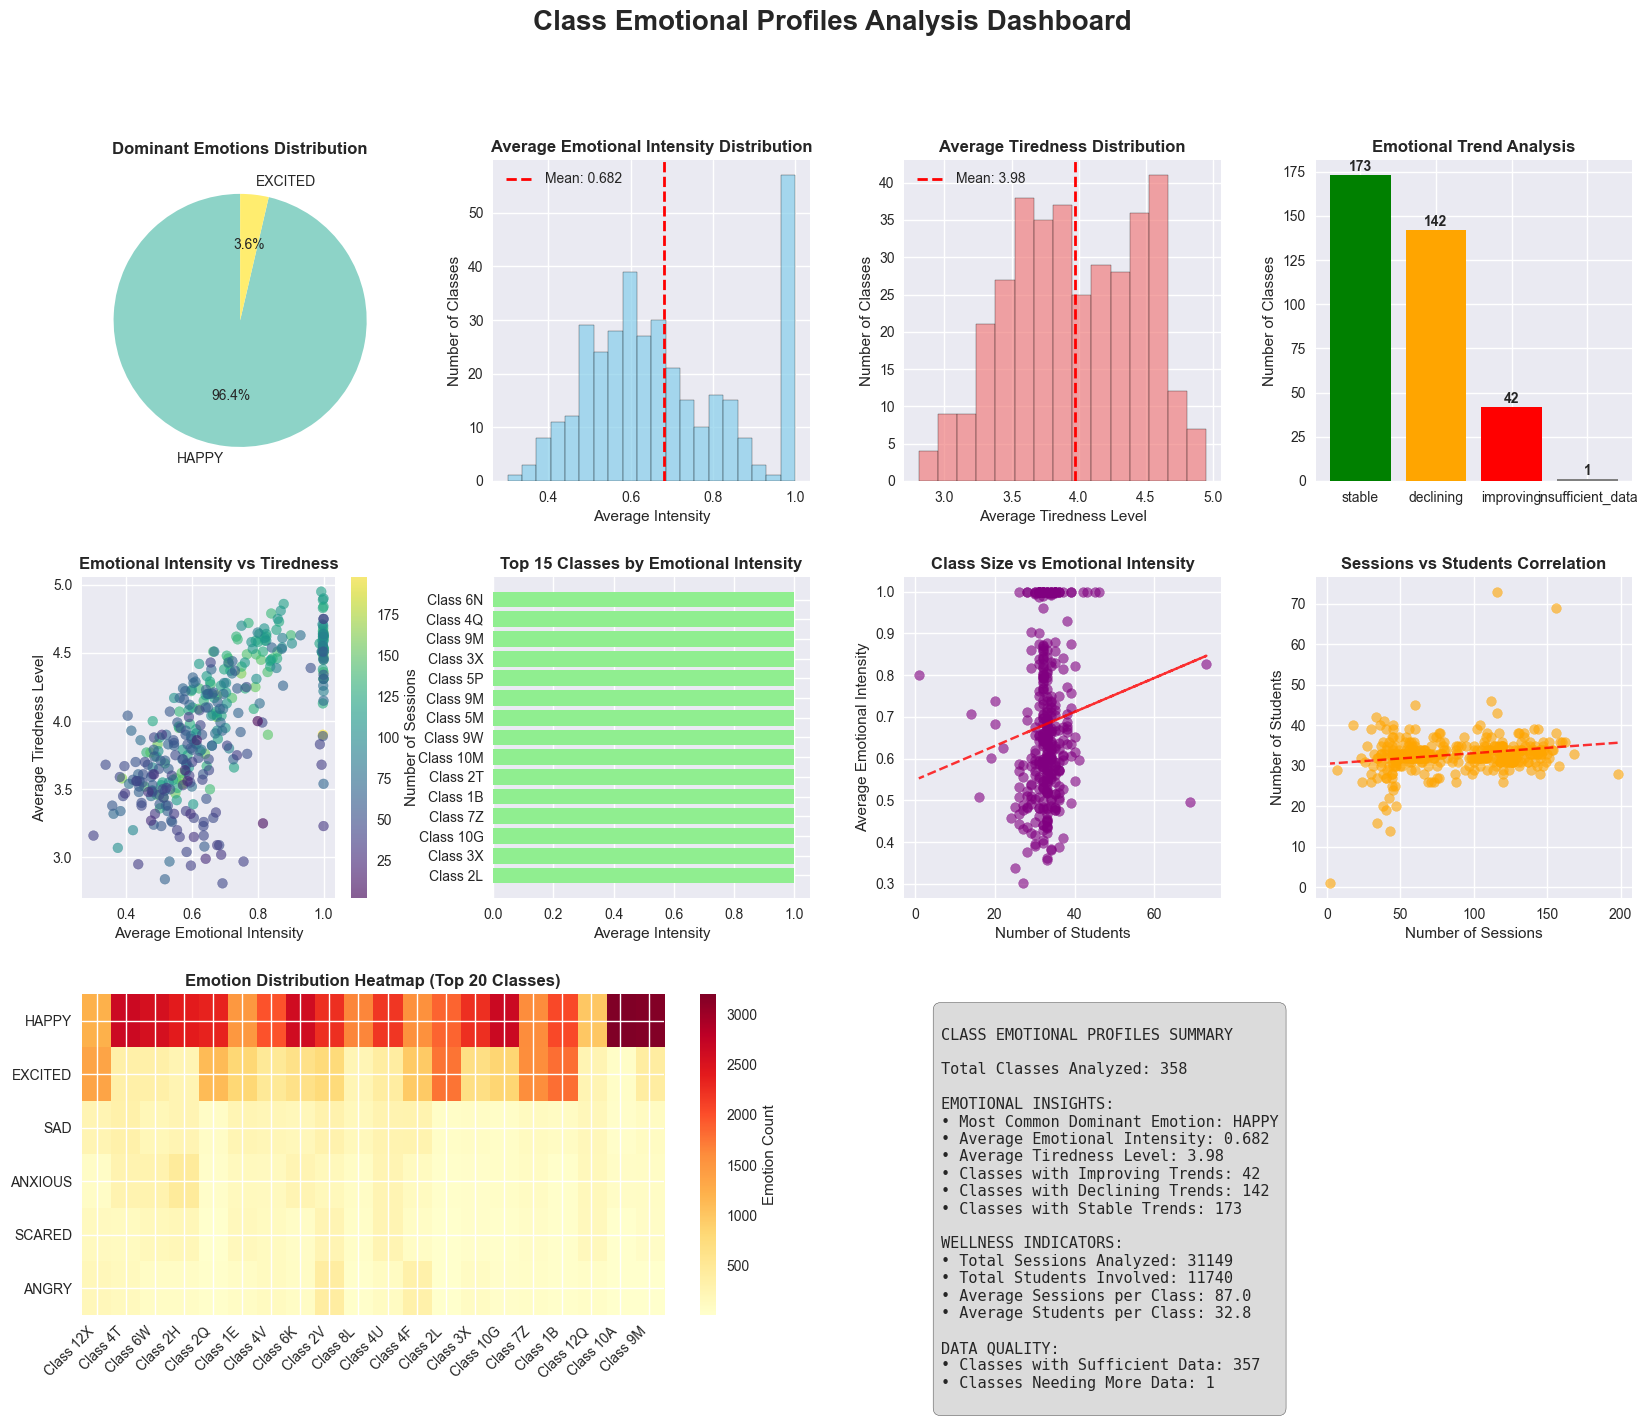

Class emotional profiles visualization completed successfully


In [23]:
# Create comprehensive visualizations of class emotional profiles
print("Creating visualizations for class emotional profiles...")

# Extract data for visualization
dominant_emotions = [profile['emotions']['dominant_emotion'] for profile in class_profiles.values()]
avg_intensities = [profile['emotions']['avg_intensity'] for profile in class_profiles.values()]
avg_tiredness = [profile['wellness_indicators']['avg_tiredness'] for profile in class_profiles.values()]
trends = [profile['trend_analysis']['trend'] for profile in class_profiles.values()]
session_counts = [profile['total_sessions'] for profile in class_profiles.values()]
student_counts = [profile['total_students'] for profile in class_profiles.values()]

# Create comprehensive visualization dashboard
fig = plt.figure(figsize=(20, 15))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)
fig.suptitle('Class Emotional Profiles Analysis Dashboard', fontsize=20, fontweight='bold', y=0.98)

# 1. Dominant emotions distribution
ax1 = fig.add_subplot(gs[0, 0])
emotion_counts = pd.Series(dominant_emotions).value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(emotion_counts)))
wedges, texts, autotexts = ax1.pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%',
                                   colors=colors, startangle=90)
ax1.set_title('Dominant Emotions Distribution', fontweight='bold', fontsize=12)

# 2. Average emotional intensity distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(avg_intensities, bins=20, color='skyblue', alpha=0.7, edgecolor='black')
ax2.set_title('Average Emotional Intensity Distribution', fontweight='bold', fontsize=12)
ax2.set_xlabel('Average Intensity')
ax2.set_ylabel('Number of Classes')
ax2.axvline(np.mean(avg_intensities), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(avg_intensities):.3f}')
ax2.legend()

# 3. Average tiredness distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(avg_tiredness, bins=15, color='lightcoral', alpha=0.7, edgecolor='black')
ax3.set_title('Average Tiredness Distribution', fontweight='bold', fontsize=12)
ax3.set_xlabel('Average Tiredness Level')
ax3.set_ylabel('Number of Classes')
ax3.axvline(np.mean(avg_tiredness), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(avg_tiredness):.2f}')
ax3.legend()

# 4. Trend analysis
ax4 = fig.add_subplot(gs[0, 3])
trend_counts = pd.Series(trends).value_counts()
bars = ax4.bar(trend_counts.index, trend_counts.values, color=['green', 'orange', 'red', 'gray'])
ax4.set_title('Emotional Trend Analysis', fontweight='bold', fontsize=12)
ax4.set_ylabel('Number of Classes')
for bar, count in zip(bars, trend_counts.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(count),
             ha='center', va='bottom', fontweight='bold')

# 5. Intensity vs Tiredness scatter plot
ax5 = fig.add_subplot(gs[1, 0])
scatter = ax5.scatter(avg_intensities, avg_tiredness, alpha=0.6, c=session_counts, cmap='viridis', s=50)
ax5.set_title('Emotional Intensity vs Tiredness', fontweight='bold', fontsize=12)
ax5.set_xlabel('Average Emotional Intensity')
ax5.set_ylabel('Average Tiredness Level')
cbar = plt.colorbar(scatter, ax=ax5)
cbar.set_label('Number of Sessions')

# 6. Top 15 classes by emotional intensity
ax6 = fig.add_subplot(gs[1, 1])
top_intensity_classes = sorted(zip([profile['class_name'] for profile in class_profiles.values()], avg_intensities),
                               key=lambda x: x[1], reverse=True)[:15]
class_names, intensities = zip(*top_intensity_classes)
bars = ax6.barh(range(len(class_names)), intensities, color='lightgreen')
ax6.set_yticks(range(len(class_names)))
ax6.set_yticklabels([name[:20] + '...' if len(name) > 20 else name for name in class_names])
ax6.set_title('Top 15 Classes by Emotional Intensity', fontweight='bold', fontsize=12)
ax6.set_xlabel('Average Intensity')

# 7. Class size vs emotional intensity (fixed: use z_students variable)
ax7 = fig.add_subplot(gs[1, 2])
z_students = np.polyfit(student_counts, avg_intensities, 1)
p_students = np.poly1d(z_students)
ax7.scatter(student_counts, avg_intensities, alpha=0.6, color='purple')
ax7.plot(student_counts, p_students(student_counts), "r--", alpha=0.8)
ax7.set_title('Class Size vs Emotional Intensity', fontweight='bold', fontsize=12)
ax7.set_xlabel('Number of Students')
ax7.set_ylabel('Average Emotional Intensity')

# 8. Sessions vs Students correlation
ax8 = fig.add_subplot(gs[1, 3])
z = np.polyfit(session_counts, student_counts, 1)
p = np.poly1d(z)
ax8.scatter(session_counts, student_counts, alpha=0.6, color='orange')
ax8.plot(session_counts, p(session_counts), "r--", alpha=0.8)
ax8.set_title('Sessions vs Students Correlation', fontweight='bold', fontsize=12)
ax8.set_xlabel('Number of Sessions')
ax8.set_ylabel('Number of Students')

# 9. Emotion distribution heatmap (top emotions)
ax9 = fig.add_subplot(gs[2, :2])
emotion_matrix = []
class_names_for_heatmap = []
top_emotions = ['HAPPY', 'EXCITED', 'SAD', 'ANXIOUS', 'SCARED', 'ANGRY']

for profile in list(class_profiles.values())[:20]:  # Top 20 classes
    class_names_for_heatmap.append(profile['class_name'][:15])
    emotion_row = []
    for emotion in top_emotions:
        count = profile['emotions']['emotion_distribution'].get(emotion, 0)
        emotion_row.append(count)
    emotion_matrix.append(emotion_row)

emotion_matrix = np.array(emotion_matrix)
im = ax9.imshow(emotion_matrix.T, cmap='YlOrRd', aspect='auto')
ax9.set_xticks(range(len(class_names_for_heatmap)))
ax9.set_xticklabels(class_names_for_heatmap, rotation=45, ha='right')
ax9.set_yticks(range(len(top_emotions)))
ax9.set_yticklabels(top_emotions)
ax9.set_title('Emotion Distribution Heatmap (Top 20 Classes)', fontweight='bold', fontsize=12)
cbar = plt.colorbar(im, ax=ax9)
cbar.set_label('Emotion Count')

# 10. Summary statistics
ax10 = fig.add_subplot(gs[2, 2:])
ax10.axis('off')
summary_text = f"""
CLASS EMOTIONAL PROFILES SUMMARY

Total Classes Analyzed: {len(class_profiles)}

EMOTIONAL INSIGHTS:
• Most Common Dominant Emotion: {pd.Series(dominant_emotions).mode().iloc[0]}
• Average Emotional Intensity: {np.mean(avg_intensities):.3f}
• Average Tiredness Level: {np.mean(avg_tiredness):.2f}
• Classes with Improving Trends: {sum(1 for t in trends if t == 'improving')}
• Classes with Declining Trends: {sum(1 for t in trends if t == 'declining')}
• Classes with Stable Trends: {sum(1 for t in trends if t == 'stable')}

WELLNESS INDICATORS:
• Total Sessions Analyzed: {sum(session_counts)}
• Total Students Involved: {sum(student_counts)}
• Average Sessions per Class: {np.mean(session_counts):.1f}
• Average Students per Class: {np.mean(student_counts):.1f}

DATA QUALITY:
• Classes with Sufficient Data: {sum(1 for t in trends if t != 'insufficient_data')}
• Classes Needing More Data: {sum(1 for t in trends if t == 'insufficient_data')}
"""
ax10.text(0.05, 0.95, summary_text, transform=ax10.transAxes, fontsize=11,
          verticalalignment='top', fontfamily='monospace',
          bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))

plt.show()

print("Class emotional profiles visualization completed successfully")


## 9. Emotional Trend Analysis
Time-series analysis of emotional trends including 7-day moving averages,
negative emotion counts per day, and trend direction classification.

In [24]:
import pandas as pd
from tqdm import tqdm
import numpy as np

# -------------------------------
# 1. Analyze emotional trends
# -------------------------------
def _analyze_emotional_trends(student_data):
    try:
        if 'Opened Date Time' not in student_data.columns or student_data.empty:
            return {'trend': 'insufficient_data'}
        
        student_data = student_data.sort_values('Opened Date Time')
        intensities = pd.to_numeric(student_data['Emotion Intensity Percentage'], errors='coerce').dropna()
        
        if len(intensities) < 2:
            return {'trend': 'insufficient_data'}
        
        recent_avg = intensities.tail(3).mean()
        earlier_avg = intensities.head(3).mean()
        
        trend = 'stable'
        if recent_avg > earlier_avg + 0.2:
            trend = 'improving'
        elif recent_avg < earlier_avg - 0.2:
            trend = 'declining'
        
        return {
            'trend': trend,
            'recent_avg_intensity': float(recent_avg),
            'earlier_avg_intensity': float(earlier_avg),
            'volatility': float(intensities.std())
        }
    except:
        return {'trend': 'insufficient_data'}


# -------------------------------
# 2. Create profiles only for filtered students
# -------------------------------
def create_emotional_profiles(filtered_students):
    try:
        profiles = {}
        unique_students = filtered_students['Student ID'].dropna().unique()

        print(f"Processing {len(unique_students)} filtered students...\n")

        for student_id in tqdm(unique_students, desc="Creating emotional profiles", unit="student"):
            student_subset = filtered_students[filtered_students['Student ID'] == student_id]
            if student_subset.empty:
                continue

            # Clean numeric data
            student_subset['Emotion Intensity Percentage'] = pd.to_numeric(
                student_subset['Emotion Intensity Percentage'], errors='coerce'
            )

            emotions = student_subset['Emotion'].dropna()
            dominant_emotion = emotions.mode().iloc[0] if not emotions.empty else 'Unknown'

            profile = {
                'student_id': student_id,
                'total_checkins': len(student_subset),
                'emotions': {
                    'dominant_emotion': dominant_emotion,
                    'avg_intensity': float(student_subset['Emotion Intensity Percentage'].mean()) if not student_subset['Emotion Intensity Percentage'].isna().all() else None,
                    'emotion_distribution': emotions.value_counts().to_dict() if not emotions.empty else {},
                    'recent_emotions': list(emotions.tail(5)) if not emotions.empty else []
                },
                'wellness_indicators': {
                    'avg_tiredness': float(pd.to_numeric(student_subset['Tiredness'], errors='coerce').mean()) if 'Tiredness' in student_subset.columns else None,
                    'chat_requests': student_subset['Request For Chat'].notna().sum(),
                    'absence_rate': (student_subset['Absencce'] != 'undefined').sum() / len(student_subset)
                },
                'trend_analysis': _analyze_emotional_trends(student_subset),
                'last_checkin': student_subset['Opened Date Time'].max() if 'Opened Date Time' in student_subset.columns else None
            }

            profiles[student_id] = profile

        print(f"\n✅ Created emotional profiles for {len(profiles)} filtered students.\n")
        return profiles

    except Exception as e:
        print(f"Error creating profiles: {e}")
        import traceback
        traceback.print_exc()
        return {}


# -------------------------------
# 3. Analyze class-level emotion
# -------------------------------
def analyze_class_emotion(profiles):
    if not profiles:
        return {"summary": "No profiles available"}

    emotions = [p['emotions']['dominant_emotion'] for p in profiles.values() if p['emotions']['dominant_emotion'] != 'Unknown']
    intensities = [p['emotions']['avg_intensity'] for p in profiles.values() if p['emotions']['avg_intensity'] is not None]

    class_dominant = pd.Series(emotions).mode().iloc[0] if emotions else 'Unknown'
    class_intensity = np.mean(intensities) if intensities else None

    summary = {
        'class_dominant_emotion': class_dominant,
        'average_intensity': round(class_intensity, 2) if class_intensity else None,
        'emotion_distribution': pd.Series(emotions).value_counts().to_dict() if emotions else {},
        'total_students': len(profiles)
    }

    return summary


# -------------------------------
# 4. Map risk / intervention
# -------------------------------
def map_intervention(class_summary):
    emotion = class_summary.get('class_dominant_emotion', 'Unknown')
    risk = 'Low'
    intervention = 'No immediate action required.'

    if emotion in ['Sad', 'Angry', 'Fear', 'Anxious']:
        risk = 'High'
        intervention = 'Schedule group discussion or counseling session.'
    elif emotion in ['Tired', 'Bored']:
        risk = 'Medium'
        intervention = 'Engage students with interactive activities.'
    elif emotion in ['Happy', 'Excited']:
        risk = 'Low'
        intervention = 'Maintain positive reinforcement and motivation.'

    return {'risk_level': risk, 'recommended_intervention': intervention}


# -------------------------------
# 5. Recommend class-level actions
# -------------------------------
def recommend_action(class_summary):
    emotion = class_summary.get('class_dominant_emotion', 'Unknown')
    recommendation = "No specific action recommended."

    if emotion == 'Sad':
        recommendation = "Introduce relaxation exercises or gratitude journaling."
    elif emotion == 'Angry':
        recommendation = "Discuss stress management and emotional control."
    elif emotion == 'Anxious':
        recommendation = "Offer mindfulness and deep breathing sessions."
    elif emotion == 'Happy':
        recommendation = "Celebrate achievements and encourage peer sharing."
    elif emotion == 'Tired':
        recommendation = "Review workload; encourage rest and healthy routines."
    
    return recommendation


# -------------------------------
# 6. Pretty printing
# -------------------------------
def print_profiles(profiles):
    for sid, p in profiles.items():
        print(f"🧍 Student ID: {sid}")
        print(f"   Dominant Emotion: {p['emotions']['dominant_emotion']}")
        print(f"   Avg Intensity: {p['emotions']['avg_intensity']}")
        print(f"   Emotion Distribution: {p['emotions']['emotion_distribution']}")
        print(f"   Trend: {p['trend_analysis']['trend']}")
        print(f"   Last Check-in: {p['last_checkin']}\n")


def print_class_summary(summary, intervention, recommendation):
    print("\n📘 CLASS EMOTION SUMMARY")
    print(f"Class Dominant Emotion: {summary['class_dominant_emotion']}")
    print(f"Average Intensity: {summary['average_intensity']}")
    print(f"Emotion Distribution: {summary['emotion_distribution']}")
    print(f"Total Students: {summary['total_students']}")
    print(f"Risk Level: {intervention['risk_level']}")
    print(f"Recommended Intervention: {intervention['recommended_intervention']}")
    print(f"Suggested Action: {recommendation}")




profiles = create_emotional_profiles(result)
print_profiles(profiles)

class_summary = analyze_class_emotion(profiles)
intervention = map_intervention(class_summary)
recommendation = recommend_action(class_summary)
print_class_summary(class_summary, intervention, recommendation)


Processing 30 filtered students...



Creating emotional profiles: 100%|██████████| 30/30 [00:00<00:00, 201.36student/s]


✅ Created emotional profiles for 30 filtered students.

🧍 Student ID: 824fbd77-fda6-4f5b-b613-7ba298691699
   Dominant Emotion: EXCITED
   Avg Intensity: 1.0
   Emotion Distribution: {'EXCITED': 1}
   Trend: insufficient_data
   Last Check-in: 2025-03-06 04:05:27.312000+00:00

🧍 Student ID: 3173234a-34c3-441d-8b72-f75b188abeff
   Dominant Emotion: HAPPY
   Avg Intensity: 1.0
   Emotion Distribution: {'HAPPY': 1}
   Trend: insufficient_data
   Last Check-in: 2025-03-06 04:05:27.312000+00:00

🧍 Student ID: a6e56f0f-8f0f-475c-b554-0cbc4aa1382a
   Dominant Emotion: HAPPY
   Avg Intensity: 1.0
   Emotion Distribution: {'HAPPY': 1}
   Trend: insufficient_data
   Last Check-in: 2025-03-06 04:05:27.312000+00:00

🧍 Student ID: e1671fc9-ee6b-4038-b789-0cc2f69075fa
   Dominant Emotion: EXCITED
   Avg Intensity: 1.0
   Emotion Distribution: {'EXCITED': 1}
   Trend: insufficient_data
   Last Check-in: 2025-03-06 04:05:27.312000+00:00

🧍 Student ID: dbed2e8e-3433-437b-84c3-78249a5537e3
   Dominant 

## Generate Class-Based Recommendations
综合分析完成后，现在生成针对每个班级的具体建议和活动推荐。


In [25]:
# ✅ Generate class-based recommendations and activity suggestions
print("Generating class-based recommendations...")

# Define activity recommendations based on emotions
activity_recommendations = {
    "HAPPY": {
        "activities": ["Group discussion", "Creative projects", "Peer teaching", "Team building games"],
        "focus": "Maintain positive energy and encourage collaboration",
        "duration": "20-30 minutes",
        "benefits": "Strengthens positive emotions and builds classroom community"
    },
    "EXCITED": {
        "activities": ["Hands-on experiments", "Interactive presentations", "Movement breaks", "Brainstorming sessions"],
        "focus": "Channel high energy into productive learning",
        "duration": "15-25 minutes",
        "benefits": "Harnesses excitement for active learning and engagement"
    },
    "SAD": {
        "activities": ["Gentle discussions", "Mindfulness exercises", "Art therapy", "Support group activities"],
        "focus": "Provide emotional support and gentle engagement",
        "duration": "10-15 minutes",
        "benefits": "Addresses emotional needs while maintaining learning momentum"
    },
    "ANXIOUS": {
        "activities": ["Breathing exercises", "Structured routines", "Clear instructions", "Stress relief techniques"],
        "focus": "Create calming environment and reduce stress",
        "duration": "5-10 minutes",
        "benefits": "Reduces anxiety and improves focus and participation"
    },
    "SCARED": {
        "activities": ["Safe space discussions", "Gradual exposure activities", "Trust building exercises", "Encouragement sessions"],
        "focus": "Build confidence and create safe learning environment",
        "duration": "10-20 minutes",
        "benefits": "Addresses fears and builds student confidence"
    },
    "ANGRY": {
        "activities": ["Conflict resolution", "Emotion regulation techniques", "Physical activities", "Cooling down exercises"],
        "focus": "Help students manage anger and redirect energy",
        "duration": "15-20 minutes",
        "benefits": "Teaches emotional regulation and conflict management"
    }
}

# ✅ Function: Generate recommendations safely
def generate_class_recommendations(class_profile):
    """Generate specific recommendations for a class based on its emotional profile"""

    # Handle missing names
    class_name = class_profile.get("class_name") or f"Unnamed_Class_{class_profile['class_id'][:8]}"

    dominant_emotion = class_profile["emotions"].get("dominant_emotion", "HAPPY")
    avg_intensity = class_profile["emotions"].get("avg_intensity", 0.5)
    avg_tiredness = class_profile["wellness_indicators"].get("avg_tiredness", 3.0)
    trend = class_profile["trend_analysis"].get("trend", "stable")
    absence_rate = class_profile["wellness_indicators"].get("absence_rate", 0)
    chat_requests = float(class_profile["wellness_indicators"].get("chat_requests", 0))

    # Base recommendation
    base_rec = activity_recommendations.get(dominant_emotion, activity_recommendations["HAPPY"])

    # Build recommendation dictionary
    recommendations = {
        "class_name": class_name,
        "class_id": class_profile["class_id"],
        "emotional_state": dominant_emotion,
        "priority_level": "HIGH" if avg_intensity > 0.8 or avg_tiredness > 4.0 else "MEDIUM",
        "recommended_activities": base_rec["activities"],
        "activity_focus": base_rec["focus"],
        "recommended_duration": base_rec["duration"],
        "expected_benefits": base_rec["benefits"],
        "custom_adjustments": [],
        "additional_considerations": [],
        "teacher_notes": ""
    }

    # Adjustments
    if avg_tiredness > 4.0:
        recommendations["custom_adjustments"].append("Consider shorter activities due to tiredness")
        recommendations["recommended_duration"] = "5-15 minutes"

    if avg_intensity < 0.3:
        recommendations["custom_adjustments"].append("Low emotional intensity - try energizing tasks")
        recommendations["recommended_activities"].extend(["Energizing music", "Movement breaks", "Interactive games"])

    if absence_rate > 0.1:
        recommendations["additional_considerations"].append(
            f"High absence rate ({absence_rate:.1%}) - check in with absent students"
        )

    if chat_requests > 5:
        recommendations["additional_considerations"].append(
            f"Multiple chat requests ({int(chat_requests)}) - students may need extra support"
        )

    if trend == "declining":
        recommendations["additional_considerations"].append(
            "Emotional trend is declining - monitor closely and provide extra support"
        )
        recommendations["priority_level"] = "HIGH"
    elif trend == "improving":
        recommendations["teacher_notes"] = "Positive trend detected - continue current strategy"

    # Add reasoning summary
    reasoning = [
        f"Dominant emotion: {dominant_emotion}",
        f"Avg intensity: {avg_intensity:.2f}",
        f"Avg tiredness: {avg_tiredness:.1f}",
        f"Trend: {trend}",
    ]
    if absence_rate > 0.05:
        reasoning.append(f"Absence rate: {absence_rate:.1%}")

    recommendations["reasoning"] = ". ".join(reasoning) + "."

    return recommendations


# ✅ Remove invalid or duplicate profiles (those without names)
class_profiles = {k: v for k, v in class_profiles.items() if v.get("class_name")}

# ✅ Generate recommendations (safe and clean)
class_recommendations = {}
for class_id, profile in class_profiles.items():
    rec = generate_class_recommendations(profile)
    class_recommendations[class_id] = rec


output_path = "class_recommendations.json"  # 
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(class_recommendations, f, indent=4)

print(f"💾 Saved class recommendations to {output_path}")
print(f"✅ Generated recommendations for {len(class_recommendations)} valid classes.")



Generating class-based recommendations...
💾 Saved class recommendations to class_recommendations.json
✅ Generated recommendations for 358 valid classes.


## Teacher Dashboard and Recommendations Summary


Creating teacher dashboard...


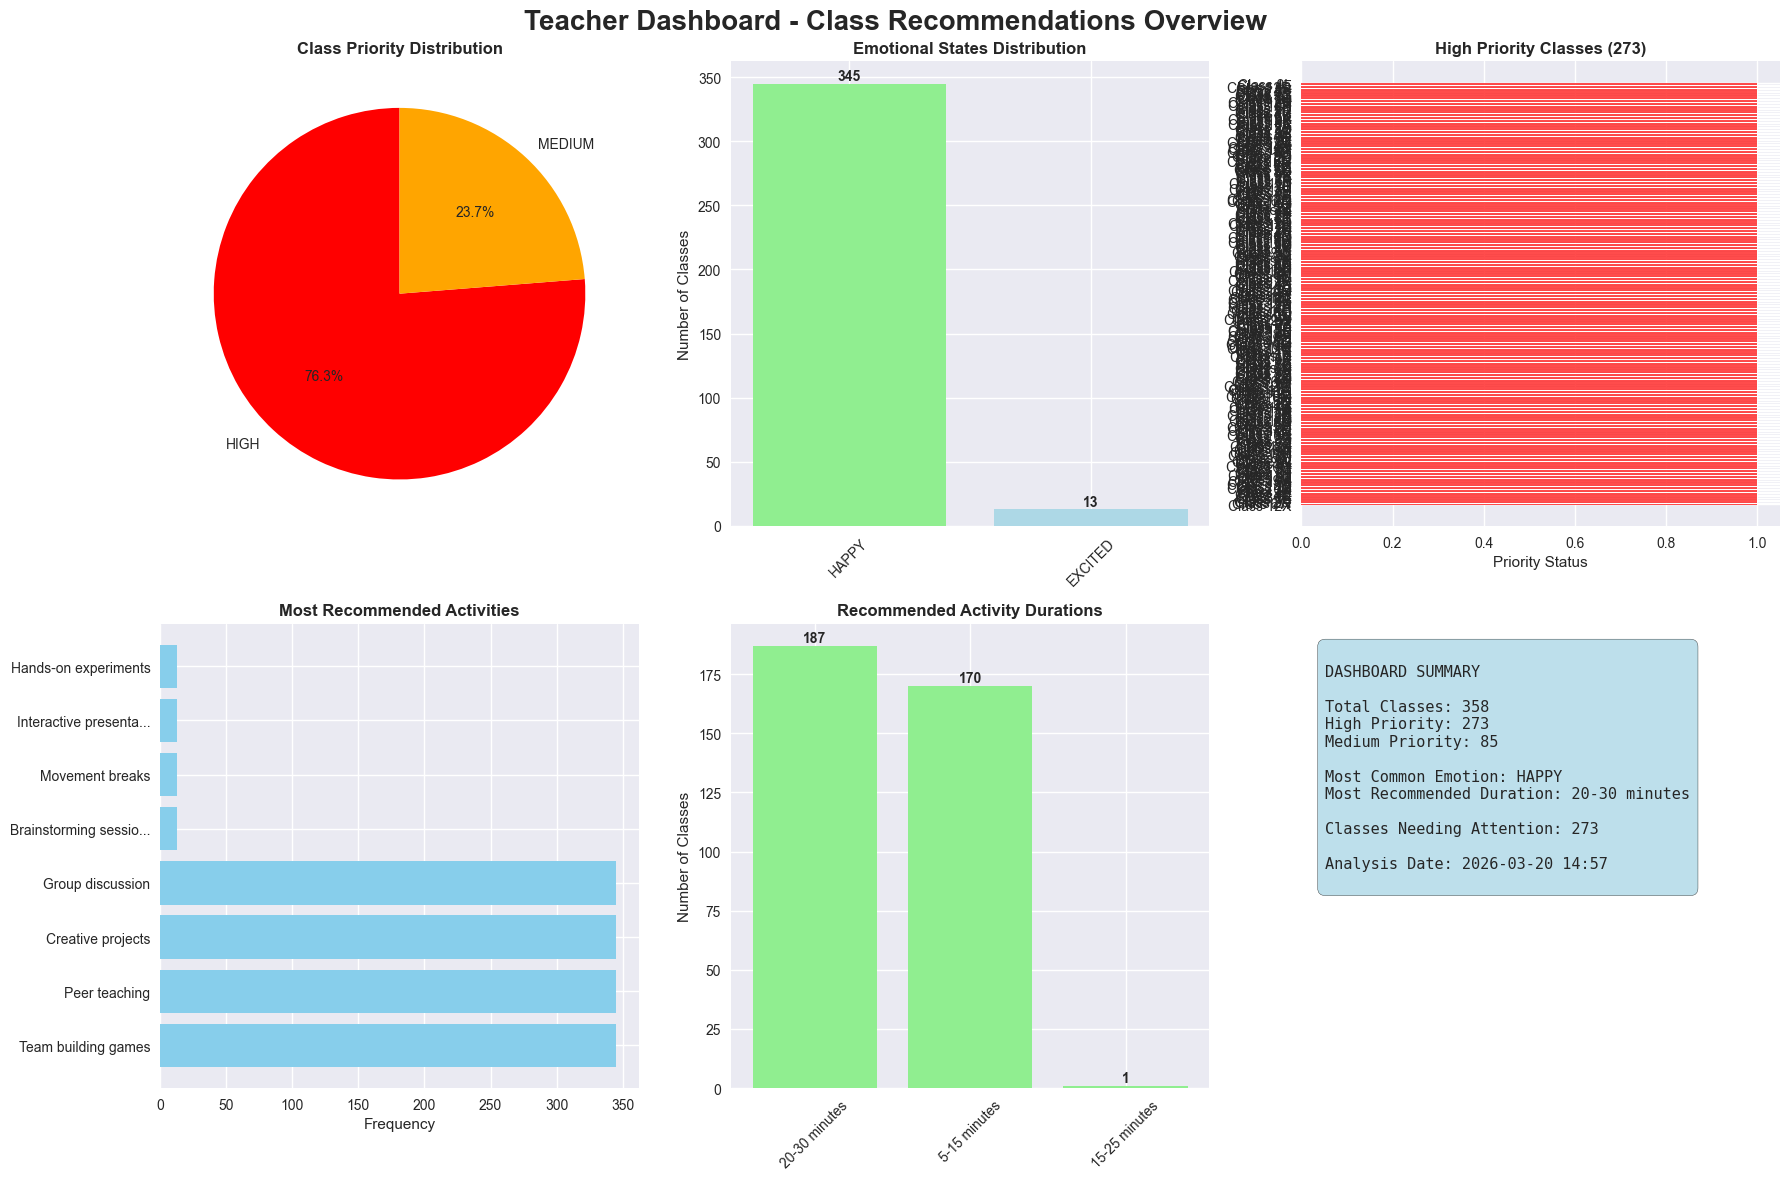


TOP 10 CLASS RECOMMENDATIONS

1. Class 9K
   Priority: HIGH
   Emotional State: HAPPY
   Recommended Activities: Group discussion, Creative projects, Peer teaching
   Duration: 20-30 minutes
   Focus: Maintain positive energy and encourage collaboration
   Considerations: High absence rate (15.0%) - check in with absent students; Emotional trend is declining - monitor closely and provide extra support

2. Class 4H
   Priority: HIGH
   Emotional State: HAPPY
   Recommended Activities: Group discussion, Creative projects, Peer teaching
   Duration: 20-30 minutes
   Focus: Maintain positive energy and encourage collaboration
   Considerations: High absence rate (11.6%) - check in with absent students; Emotional trend is declining - monitor closely and provide extra support

3. Class 6W
   Priority: HIGH
   Emotional State: HAPPY
   Recommended Activities: Group discussion, Creative projects, Peer teaching
   Duration: 20-30 minutes
   Focus: Maintain positive energy and encourage collabo

In [26]:
# Create comprehensive teacher dashboard with visualizations
print("Creating teacher dashboard...")

# Create dashboard visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Teacher Dashboard - Class Recommendations Overview', fontsize=20, fontweight='bold', y=0.98)

# 1. Priority level distribution
ax1 = axes[0, 0]
priority_counts = pd.Series([r['priority_level'] for r in class_recommendations.values()]).value_counts()
colors = ['red', 'orange', 'green']
wedges, texts, autotexts = ax1.pie(priority_counts.values, labels=priority_counts.index, autopct='%1.1f%%', 
                                   colors=colors[:len(priority_counts)], startangle=90)
ax1.set_title('Class Priority Distribution', fontweight='bold', fontsize=12)

# 2. Emotional states distribution
ax2 = axes[0, 1]
emotion_counts = pd.Series([r['emotional_state'] for r in class_recommendations.values()]).value_counts()
bars = ax2.bar(emotion_counts.index, emotion_counts.values, color=['lightgreen', 'lightblue', 'lightcoral', 'lightyellow', 'lightpink', 'lightgray'])
ax2.set_title('Emotional States Distribution', fontweight='bold', fontsize=12)
ax2.set_ylabel('Number of Classes')
ax2.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, emotion_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(count), 
             ha='center', va='bottom', fontweight='bold')

# 3. High priority classes by name
ax3 = axes[0, 2]
high_priority_classes = [r['class_name'] for r in class_recommendations.values() if r['priority_level'] == 'HIGH']
if high_priority_classes:
    bars = ax3.barh(range(len(high_priority_classes)), [1]*len(high_priority_classes), color='red', alpha=0.7)
    ax3.set_yticks(range(len(high_priority_classes)))
    ax3.set_yticklabels([name[:25] + '...' if len(name) > 25 else name for name in high_priority_classes])
    ax3.set_title(f'High Priority Classes ({len(high_priority_classes)})', fontweight='bold', fontsize=12)
    ax3.set_xlabel('Priority Status')
else:
    ax3.text(0.5, 0.5, 'No High Priority Classes', ha='center', va='center', transform=ax3.transAxes, fontsize=14)
    ax3.set_title('High Priority Classes', fontweight='bold', fontsize=12)

# 4. Activity recommendations frequency
ax4 = axes[1, 0]
all_activities = []
for rec in class_recommendations.values():
    all_activities.extend(rec['recommended_activities'])
activity_counts = pd.Series(all_activities).value_counts().head(10)
bars = ax4.barh(range(len(activity_counts)), activity_counts.values, color='skyblue')
ax4.set_yticks(range(len(activity_counts)))
ax4.set_yticklabels([act[:20] + '...' if len(act) > 20 else act for act in activity_counts.index])
ax4.set_title('Most Recommended Activities', fontweight='bold', fontsize=12)
ax4.set_xlabel('Frequency')

# 5. Duration recommendations
ax5 = axes[1, 1]
duration_counts = pd.Series([r['recommended_duration'] for r in class_recommendations.values()]).value_counts()
bars = ax5.bar(duration_counts.index, duration_counts.values, color='lightgreen')
ax5.set_title('Recommended Activity Durations', fontweight='bold', fontsize=12)
ax5.set_ylabel('Number of Classes')
ax5.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, duration_counts.values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(count), 
             ha='center', va='bottom', fontweight='bold')

# 6. Summary statistics
ax6 = axes[1, 2]
ax6.axis('off')
summary_stats = f"""
DASHBOARD SUMMARY

Total Classes: {len(class_recommendations)}
High Priority: {len([r for r in class_recommendations.values() if r['priority_level'] == 'HIGH'])}
Medium Priority: {len([r for r in class_recommendations.values() if r['priority_level'] == 'MEDIUM'])}

Most Common Emotion: {pd.Series([r['emotional_state'] for r in class_recommendations.values()]).mode().iloc[0]}
Most Recommended Duration: {pd.Series([r['recommended_duration'] for r in class_recommendations.values()]).mode().iloc[0]}

Classes Needing Attention: {len(high_priority_classes)}

Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}
"""
ax6.text(0.05, 0.95, summary_stats, transform=ax6.transAxes, fontsize=11, 
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))

plt.tight_layout()
plt.show()

# Display top 10 class recommendations
print("\n" + "="*80)
print("TOP 10 CLASS RECOMMENDATIONS")
print("="*80)

top_recommendations = sorted(class_recommendations.values(), 
                           key=lambda x: (x['priority_level'] == 'HIGH', len(x['additional_considerations'])), 
                           reverse=True)[:10]

for i, rec in enumerate(top_recommendations, 1):
    print(f"\n{i}. {rec['class_name']}")
    print(f"   Priority: {rec['priority_level']}")
    print(f"   Emotional State: {rec['emotional_state']}")
    print(f"   Recommended Activities: {', '.join(rec['recommended_activities'][:3])}")
    print(f"   Duration: {rec['recommended_duration']}")
    print(f"   Focus: {rec['activity_focus']}")
    if rec['additional_considerations']:
        print(f"   Considerations: {'; '.join(rec['additional_considerations'])}")

print("\n" + "="*80)
print("TEACHER DASHBOARD COMPLETED SUCCESSFULLY")
print("="*80)


## Save Results and Export Data


In [27]:
# Save all results to files for future use
print("Saving analysis results...")

# Save class profiles to JSON
profiles_output = {
    "analysis_metadata": {
        "analysis_date": datetime.now().isoformat(),
        "total_classes_analyzed": len(class_profiles),
        "data_source": "studentCheckIn_cleaned.csv",
        "analysis_type": "class_based_emotional_profiling"
    },
    "class_profiles": class_profiles
}

with open('class_emotional_profiles.json', 'w', encoding='utf-8') as f:
    json.dump(profiles_output, f, indent=2, ensure_ascii=False, default=str)

print(f"Class profiles saved to: class_emotional_profiles.json")

# Save recommendations to JSON (fixed: removed undefined teacher_dashboard variable)
recommendations_output = {
    "analysis_metadata": {
        "analysis_date": datetime.now().isoformat(),
        "total_recommendations": len(class_recommendations),
        "high_priority_count": len([r for r in class_recommendations.values() if r['priority_level'] == 'HIGH']),
        "most_common_emotion": pd.Series([r['emotional_state'] for r in class_recommendations.values()]).mode().iloc[0]
    },
    "class_recommendations": class_recommendations
}

with open('class_recommendations.json', 'w', encoding='utf-8') as f:
    json.dump(recommendations_output, f, indent=2, ensure_ascii=False, default=str)

print(f"Class recommendations saved to: class_recommendations.json")

# Create summary CSV for easy viewing
summary_data = []
for class_id, profile in class_profiles.items():
    rec = class_recommendations.get(class_id, {})
    summary_data.append({
        'class_id': profile['class_id'],
        'class_name': profile['class_name'],
        'total_sessions': profile['total_sessions'],
        'total_students': profile['total_students'],
        'dominant_emotion': profile['emotions']['dominant_emotion'],
        'avg_intensity': profile['emotions']['avg_intensity'],
        'avg_tiredness': profile['wellness_indicators']['avg_tiredness'],
        'absence_rate': profile['wellness_indicators']['absence_rate'],
        'trend': profile['trend_analysis']['trend'],
        'priority_level': rec.get('priority_level', 'UNKNOWN'),
        'recommended_activities': '; '.join(rec.get('recommended_activities', [])),
        'recommended_duration': rec.get('recommended_duration', 'N/A'),
        'last_session': profile['last_session']
    })

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('class_analysis_summary.csv', index=False)
print(f"Summary CSV saved to: class_analysis_summary.csv")

print("\n" + "="*60)
print("ANALYSIS COMPLETION SUMMARY")
print("="*60)
print(f"Total classes analyzed: {len(class_profiles)}")
print(f"High priority classes: {len([r for r in class_recommendations.values() if r['priority_level'] == 'HIGH'])}")
print(f"Medium priority classes: {len([r for r in class_recommendations.values() if r['priority_level'] == 'MEDIUM'])}")
print(f"Most common emotion: {pd.Series([r['emotional_state'] for r in class_recommendations.values()]).mode().iloc[0]}")
print(f"Analysis date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("\nFiles created:")
print("- class_emotional_profiles.json (detailed class profiles)")
print("- class_recommendations.json (teacher recommendations)")
print("- class_analysis_summary.csv (summary table)")
print("="*60)
print("ANALYSIS COMPLETED SUCCESSFULLY")
print("="*60)


Saving analysis results...
Class profiles saved to: class_emotional_profiles.json
Class recommendations saved to: class_recommendations.json
Summary CSV saved to: class_analysis_summary.csv

ANALYSIS COMPLETION SUMMARY
Total classes analyzed: 358
High priority classes: 273
Medium priority classes: 85
Most common emotion: HAPPY
Analysis date: 2026-03-20 14:57:32

Files created:
- class_emotional_profiles.json (detailed class profiles)
- class_recommendations.json (teacher recommendations)
- class_analysis_summary.csv (summary table)
ANALYSIS COMPLETED SUCCESSFULLY
